In [1]:
results_path = "hybrid_outputs"

In [2]:
# check hybrid
import os
import re
from collections import Counter

slurm_files = [f for f in os.listdir(results_path) if f.startswith("slurm") and f.endswith(".out")]

# Count failed runs (runs with any NaN metric line) by version/temp combo.
failed_by_combo = Counter()
seen_runs_by_combo = Counter()

nan_token = re.compile(r"(?<![A-Za-z0-9_])-?nan(?![A-Za-z0-9_])", re.IGNORECASE)

for slurm_file in slurm_files:
    with open(os.path.join(results_path, slurm_file), "r") as f:
        current_combo = None
        run_has_nan = False
        run_started = False

        for raw_line in f:
            line = raw_line.strip()

            if line.startswith("Combo:"):
                # Example: Combo: 2015_2018:6:RMM:density_dependent:Langmuir:Cp,Cm
                parts = line.replace("Combo:", "", 1).strip().split(":")
                if len(parts) >= 5:
                    temp = parts[0]
                    md, mt, sat = parts[2], parts[3], parts[4]
                    version = f"{md}+{mt}+{sat}"
                    current_combo = f"{version}|{temp}"
                else:
                    current_combo = line.replace("Combo:", "", 1).strip()

                # Reset state whenever the combo header changes.
                run_has_nan = False
                run_started = False

            elif line.startswith("init y_loss"):
                # Start of a new run within the current combo.
                run_has_nan = False
                run_started = True

            elif line.startswith("step"):
                if run_started and nan_token.search(line):
                    run_has_nan = True

            elif line.startswith("total_time_sec"):
                # Count only completed runs.
                if current_combo is not None and run_started:
                    seen_runs_by_combo[current_combo] += 1
                    if run_has_nan:
                        failed_by_combo[current_combo] += 1
                run_has_nan = False
                run_started = False

if not seen_runs_by_combo:
    print("No runs found.")
else:
    # Re-group as temp -> version and print all 12 md+mt+sat versions per temp.
    all_versions = [
        f"{md}+{mt}+{sat}"
        for md in ["linear", "MM", "RMM"]
        for mt in ["linear", "density_dependent"]
        for sat in ["no", "Langmuir"]
    ]

    grouped = {}
    for combo, total in seen_runs_by_combo.items():
        version, temp = combo.split("|", 1)
        failed = failed_by_combo.get(combo, 0)
        grouped.setdefault(temp, {})[version] = (failed, total)

    temp_order = ["static", "dynamic"]
    print("failed/total\ttemp\tversion")
    for temp in temp_order:
        if temp not in grouped:
            continue
        for version in all_versions:
            failed, total = grouped[temp].get(version, (0, 0))
            print(f"{failed}/{total}\t{temp}\t{version}")

failed/total	temp	version
0/72	static	linear+linear+no
0/72	static	linear+linear+Langmuir
0/84	static	linear+density_dependent+no
0/84	static	linear+density_dependent+Langmuir
0/48	static	MM+linear+no
0/48	static	MM+linear+Langmuir
0/60	static	MM+density_dependent+no
0/60	static	MM+density_dependent+Langmuir
0/48	static	RMM+linear+no
0/48	static	RMM+linear+Langmuir
0/60	static	RMM+density_dependent+no
0/60	static	RMM+density_dependent+Langmuir


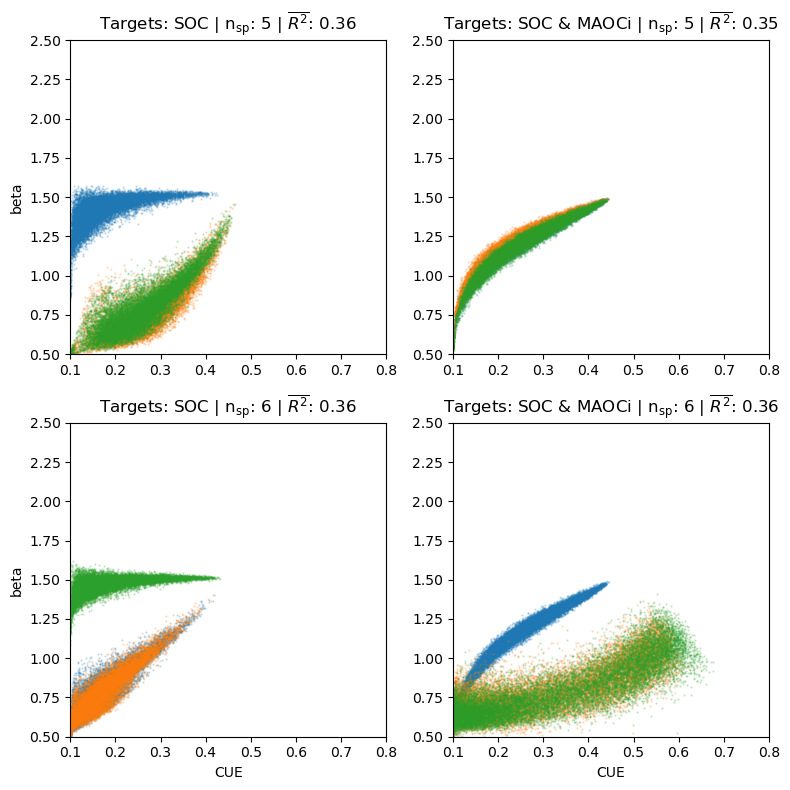

In [38]:
# scatter plots of equifinality (ß vs. CUE)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import os
from config import default_param_ranges, default_state_bounds

x_var = 'CUE'
y_var = 'beta'
temp = 'dynamic'
target_combis = ['SOC', 'SOC-MAOCi']
n = [5, 6]
md = 'RMM'
mt = 'density_dependent'
sat = 'Langmuir'
x_xy = 'xy'
size = 4

folds = 3

def r2(y, y_p):
    y = np.asarray(y)
    y_p = np.asarray(y_p)
    ss_res = np.sum((y - y_p) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

all_files = os.listdir(results_path)

translate = {
    'Cp': 'POC',
    'Cm': 'MAOC',
    'Cb': 'MIC'
}

def determination(x_var, y_var, temp, target_combis, n, md, mt, sat, x_xy, filename, shape):
    fig, axes = plt.subplots(nrows=len(n), ncols=len(target_combis), figsize=(size*len(target_combis), size*len(n)))
    if len(n) == 1 and len(target_combis) == 1:
        axes = np.array([[axes]])
    elif len(n) == 1 or len(target_combis) == 1:
        axes = axes.reshape(len(n), len(target_combis))
    all_x, all_y = [], []
    cmap = plt.cm.tab10
    for r, n_sp in enumerate(n):
        for c, tar in enumerate(target_combis):
            ax = axes[r, c]
            arr = np.full((folds, len(tar.split('-'))), np.nan)
            for fold in range(folds):
                files = [
                    f for f in all_files
                    if f"md{md}" in f and f"mt{mt}" in f and f"sat{sat}" in f
                    and f"fold{fold}" in f and f"{tar}_" in f and f"temp{temp}_fold" in f
                ]
                files = sorted(files, key=len, reverse=True)
                data = pd.read_pickle(os.path.join(results_path, files[n_sp]))

                for t_i, t in enumerate(tar.split('-')):
                    y = data.get(f"target_{t}")
                    y_p = data.get(f"pred_{t}")
                    arr[fold, t_i] = r2(y, y_p)
                x_vals = data.get(f"param_{x_var}")
                y_vals = data.get(f"param_{y_var}")
                ax.scatter(x_vals, y_vals, color=cmap(fold / 10), label=f'Fold {fold}', alpha=0.2, s=0.5)
            med = np.median(arr, axis=0)
            mean = np.mean(med, axis=0)
            ax.set_xlim(default_param_ranges[x_var]["min"], default_param_ranges[x_var]["max"])
            ax.set_ylim(default_param_ranges[y_var]["min"], default_param_ranges[y_var]["max"])
            ax.set_title(f"Targets: {' & '.join([translate.get(t, t) for t in tar.split('-')])} | n$_{{\\mathrm{{sp}}}}$: {n_sp} | $\\overline{{R^2}}$: {mean:.2f}")
            if c == 0:
                ax.set_ylabel(y_var)
            if r == len(n) - 1:
                ax.set_xlabel(x_var)

    plt.tight_layout()
    plt.savefig(f'figures/{filename}.png', dpi=300, bbox_inches='tight')
    plt.show()

determination(x_var, y_var, temp, target_combis, n, md, mt, sat, x_xy, 'CUE_beta_scatter_determination.png', 'points')

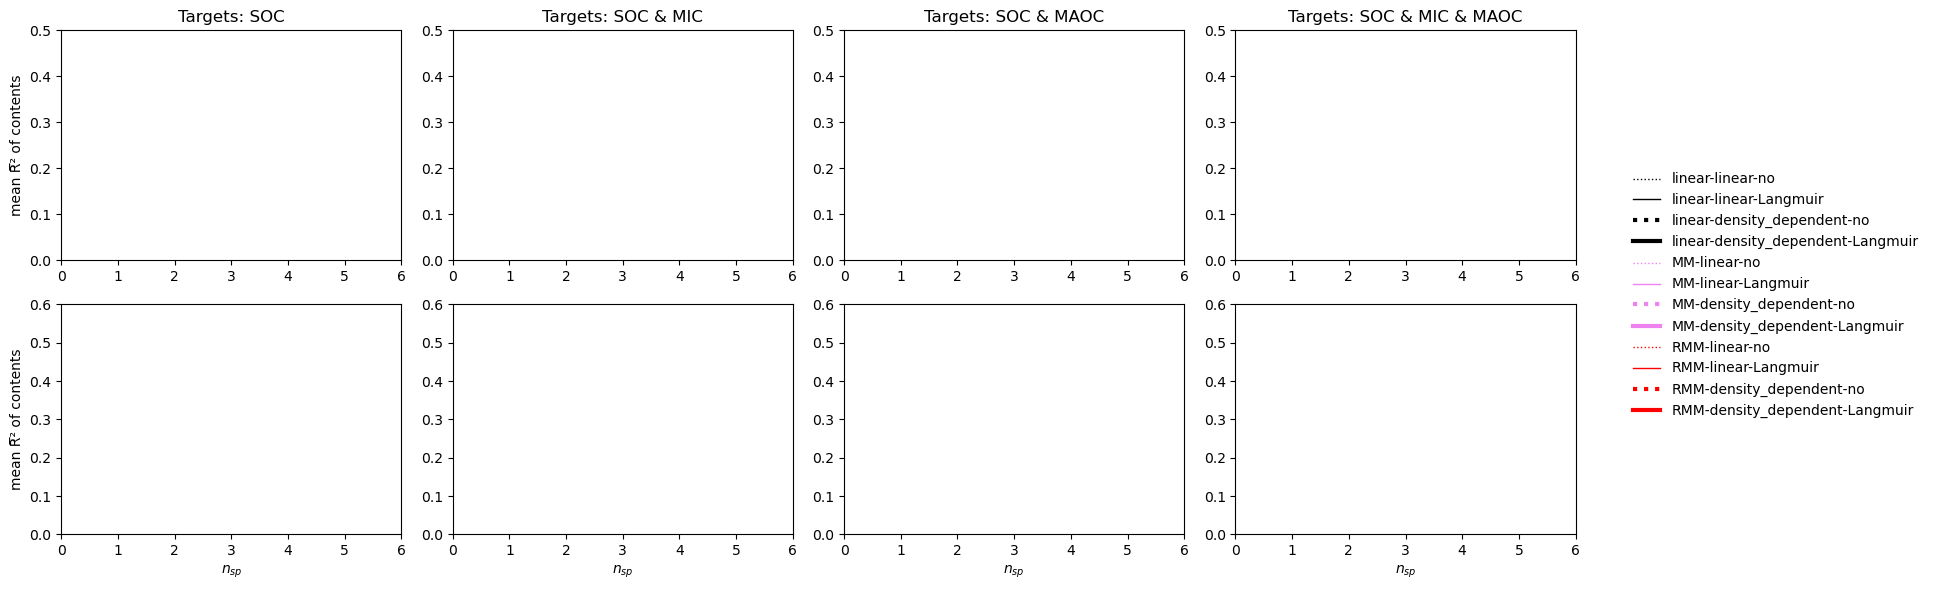

In [6]:
# adaptability
from doctest import ELLIPSIS_MARKER
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

lucas = pd.read_pickle("1_preprocessed.pkl")
split = lucas['split']
folds = 6

# numpy pickle-compat shim: some pickles reference numpy._core.*
import sys
import numpy.core.numeric as _np_core_numeric
sys.modules.setdefault("numpy._core.numeric", _np_core_numeric)

def r2_like_training(y_target, y_pred_compare):
    y_target = np.asarray(y_target)
    y_pred_compare = np.asarray(y_pred_compare)
    ss_res = np.sum((y_target - y_pred_compare) ** 2, axis=0)
    ss_tot = np.sum((y_target - np.mean(y_target, axis=0)) ** 2, axis=0)
    return 1.0 - ss_res / (ss_tot + 1e-12)


def n_globals_from_filename(file_name):
    globals_part = file_name.rsplit("_globals", 1)[-1].removesuffix(".pkl")
    if globals_part == "none":
        return 0
    return len(globals_part.split("-"))


def fold_valid_indices(data, fold):
    fold_idx = split[split == fold].index
    return fold_idx.intersection(data.index)

versions = {}
for md in ["linear", "MM", "RMM"]:
    for mt in ["linear", "density_dependent"]:
        for sat in ["no", "Langmuir"]:
            file_sub_str = f"md{md}_mt{mt}_sat{sat}"

            # colors by md
            color_map = {
                "linear": "black",   # linear md -> black
                "MM": "violet",      # MM -> violet
                "RMM": "red",        # RMM -> red
            }

            # line width by mt
            linewidth = 1 if mt == "linear" else 3  # linear mt thin, density_dependent thick

            # line style by saturation
            linestyle = ":" if sat == "no" else "-"  # no saturation dotted, Langmuir continuous

            versions[file_sub_str] = {
                "color": color_map[md],
                "texture": linestyle,          # reuse existing 'texture' field for linestyle
                "linewidth": linewidth,
                "legend": f"{md}-{mt}-{sat}",
            }

def first_max_index(values, tol=0.02):
    values = np.asarray(values)
    valid = ~np.isnan(values)
    if not np.any(valid):
        # If no valid values, return safe defaults (avoiding crash)
        return 0, -1, np.nan
    valid_values = values[valid]
    max_val = np.max(valid_values)
    threshold = max_val - tol
    # Find first index in the original array (not just valid indices)
    for i, v in enumerate(values):
        if not np.isnan(v) and v >= threshold:
            return len(values), i, v
    # Fallback if not found
    return len(values), -1, np.nan

def plot(temps, filename):
    all_files = os.listdir(results_path)
    fig, axes = plt.subplots(nrows=len(temps), ncols=4, figsize=(16, 3*len(temps)))
    results = []
    for row_i, temp in enumerate(temps): # temp
        for col_i, targets in enumerate(["SOC", "SOC-MICi", "SOC-MAOCi", "SOC-MAOCi-MICi"]): # targets
            if len(temps) == 1:
                ax = axes[col_i]
            else:
                ax = axes[row_i, col_i]
            for version in versions:
                arr = np.full((folds, 3, 20), np.nan)
                for fold in range(folds): # loop over folds
                    files = [f for f in all_files
                        if version in f
                        and f"fold{fold}" in f
                        and f"{targets}_" in f
                        and f"temp{temp}_fold" in f]
                    files = sorted(files, key=len, reverse=True)
                    for f, file in enumerate(files): # loop over existing files (spatially varying parameters)
                        data = pd.read_pickle(os.path.join(results_path, file)) # load pkl
                        valid = fold_valid_indices(data, fold) # match validation fold to exactly saved samples
                        data = data.loc[valid]
                        target_names = targets.split('-')
                        y = data[[f"target_{tar}" for tar in target_names]].to_numpy()
                        y_p = data[[f"pred_{tar}" for tar in target_names]].to_numpy()
                        r2_vec = r2_like_training(y, y_p)
                        arr[fold, :len(target_names), f] = r2_vec
                # Remove spatial parameter dimensions that are all nan
                arr_nonan = arr[:, :, ~np.all(np.isnan(arr), axis=(0,1))]  # remove spatial parameters which are not there
                if arr_nonan.size == 0:
                    # No data, skip to next version
                    continue
                arr_nonan = arr_nonan[:, ~np.all(np.isnan(arr_nonan), axis=(0, 2)), :]  # keep only existing targets
                if arr_nonan.size == 0:
                    # After filtering, still empty, skip.
                    continue
                med = np.median(arr_nonan, axis=0) # median along folds
                mean = np.mean(med, axis=0)  # remove a dim after mean along folds
                style = versions[version]
                ax.plot(np.arange(len(mean)), mean, # data
                    label=version,
                    color=style["color"],linestyle=style["texture"],linewidth=style["linewidth"])
                try:
                    total, best_index, best_meanR2 = first_max_index(mean, tol=0.02)
                except Exception:
                    # In case something still goes wrong (empty mean), fall back
                    total, best_index, best_meanR2 = 0, -1, np.nan
                results.append({
                    "version": version,
                    "targets": targets,
                    "temp": temp,
                    "optimal n_sp": best_index,
                    "max n_sp": total,
                    "best mean R2": best_meanR2
                })

    targets_list = ["Targets: SOC", "Targets: SOC & MIC", "Targets: SOC & MAOC", "Targets: SOC & MIC & MAOC"]

    x_max = max((len(line.get_xdata()) for ax in axes.ravel() for line in ax.get_lines()), default=1) - 1
    for r, t in enumerate(temps):
        for c, tar in enumerate(targets_list):
            if len(temps) == 1:
                ax = axes[c]
            else:
                ax = axes[r, c]
            if r == 0:
                ax.set_title(tar)
            if c == 0 and r in [0,1]:
                ax.set_ylabel(f"mean R\u0305² of contents")
            if c == 0 and r in [2]:
                ax.set_ylabel(f"mean R\u0305² of changes")
            if r == len(temps) - 1:
                ax.set_xlabel("$n_{sp}$")

    for row_i, temp in enumerate(temps): # temp
        for col_i, targets in enumerate(["SOC", "SOC-MICi", "SOC-MAOCi", "SOC-MAOCi-MICi"]): # targets
            if len(temps) == 1:
                ax = axes[col_i]
            else:
                ax = axes[row_i, col_i]
            if row_i == 1:
                ax.set_ylim(0, 0.6)
            else:
                ax.set_ylim(0, 0.5)
            ax.set_xlim(0, x_max)    

    # Build one legend entry per version (using stored styles)
    legend_elements = []
    for version, style in versions.items():
        legend_elements.append(
            Line2D(
                [0], [0],
                color=style["color"],
                linestyle=style["texture"],
                linewidth=style["linewidth"],
                label=style["legend"],   # or label=version
            )
        )

    # Single legend next to the parent plot
    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.,
        frameon=False)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")

    return pd.DataFrame(results)

res_1 = plot(["static", "dynamic"], 'figures/line_adaptability_grid_main.png')
# res_2 = plot(["2015"], 'figures/line_adaptability_grid_supp.png')
# res = pd.concat([res_1, res_2], ignore_index=True)
res_1.to_csv("figures/adaptability_grid_results.csv", index=False)

In [5]:
### pick versions for SfT, CUE and Qmax analysis

# Load results from the saved CSV (do not use in-memory 'res')
import pandas as pd
res = pd.read_csv("figures/adaptability_grid_results.csv")




res_2015_2018 = res[(res["temp"] != "static") & (res["targets"] == "SOC-MAOCi-MICi")]
res_2015_2018 = res_2015_2018.sort_values(['temp', 'best mean R2'], ascending=[True, False])
# Split the 'version' column into 'md', 'mt', and 'sat' columns
def parse_version(v):
    # version format: md{md}_mt{mt}_sat{sat}
    parts = v.split("_")
    md = parts[0][2:]
    mt = "_".join(parts[1:-1])[2:]
    sat = parts[-1][3:]
    return pd.Series([md, mt, sat])

res_2015_2018[["decomposition", "microbial turnover", "saturation"]] = res_2015_2018["version"].apply(parse_version)
selected = res_2015_2018[(res_2015_2018["temp"] == "dynamic") & (res_2015_2018["microbial turnover"].str.contains("density_dependent"))]
selected_2 = res_2015_2018[(res_2015_2018["temp"] == "dynamic") & (res_2015_2018["microbial turnover"].str.contains("density_dependent"))]
# res_2015_2018 = res_2015_2018.drop(columns=["version"])
res_2015_2018.to_csv("figures/res_2015_2018.csv", index=False)




# SfT: best 2015_2018 with all targets -> all density_dependent
# CUE: best 2015_2018 with all targets
# Qmax: best 2015_2018 with all targets + Cg0m active -> all density_dependent with Langmuir (try if actually active)
res_2015_2018

,version,targets,temp,optimal n_sp,max n_sp,best mean R2,decomposition,microbial turnover,saturation
93,mdRMM_mtlinear_satLangmuir,SOC-MAOCi-MICi,dynamic,6,8,0.525366,RMM,linear,Langmuir
92,mdRMM_mtlinear_satno,SOC-MAOCi-MICi,dynamic,6,8,0.518446,RMM,linear,no
94,mdRMM_mtdensity_dependent_satno,SOC-MAOCi-MICi,dynamic,7,9,0.514590,RMM,density_dependent,no
88,mdMM_mtlinear_satno,SOC-MAOCi-MICi,dynamic,7,8,0.511628,MM,linear,no
95,mdRMM_mtdensity_dependent_satLangmuir,SOC-MAOCi-MICi,dynamic,7,9,0.511012,RMM,density_dependent,Langmuir
90,mdMM_mtdensity_dependent_satno,SOC-MAOCi-MICi,dynamic,7,9,0.507866,MM,density_dependent,no
89,mdMM_mtlinear_satLangmuir,SOC-MAOCi-MICi,dynamic,6,8,0.495422,MM,linear,Langmuir
91,mdMM_mtdensity_dependent_satLangmuir,SOC-MAOCi-MICi,dynamic,7,9,0.483921,MM,density_dependent,Langmuir
86,mdlinear_mtdensity_dependent_satno,SOC-MAOCi-MICi,dynamic,5,7,0.472967,linear,density_dependent,no
87,mdlinear_mtdensity_dependent_satLangmuir,SOC-MAOCi-MICi,dynamic,4,7,0.472161,linear,density_dependent,Langmuir


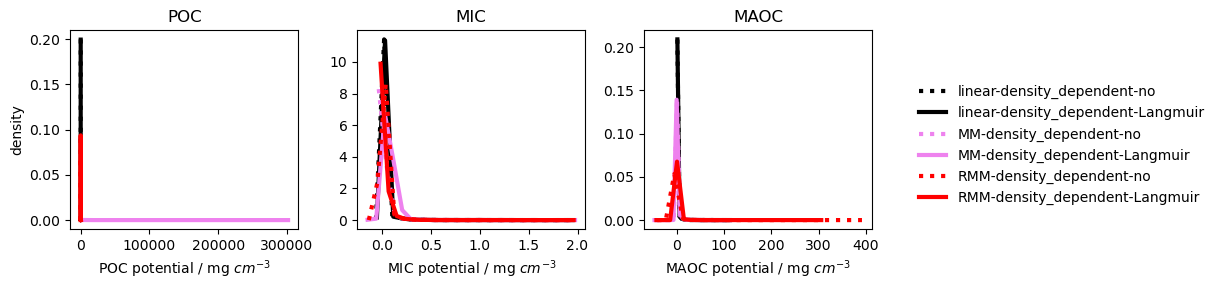

In [6]:
### SfT
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import numpy as np
folds = 3

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*3, 3)) # 3 subplots (3 pools)
versions = {} # selected versions (density_dependent)
for md in ["linear", "MM", "RMM"]:
    for mt in ["density_dependent"]:
        for sat in ["no", "Langmuir"]:
            file_sub_str = f"md{md}_mt{mt}_sat{sat}"

            # colors by md
            color_map = {
                "linear": "black",   # linear md -> black
                "MM": "violet",      # MM -> violet
                "RMM": "red",        # RMM -> red
            }

            # line width by mt
            linewidth = 1 if mt == "linear" else 3  # linear mt thin, density_dependent thick

            # line style by saturation
            linestyle = ":" if sat == "no" else "-"  # no saturation dotted, Langmuir continuous

            versions[file_sub_str] = {
                "color": color_map[md],
                "texture": linestyle,          # reuse existing 'texture' field for linestyle
                "linewidth": linewidth,
                "legend": f"{md}-{mt}-{sat}",
                "md": md,
                "mt": mt,
                "sat": sat,
            }
all_files = os.listdir(results_path) 
import jax
from functools import partial
from models import analytical_steady_state

# Build a mask for "selected" DataFrame that matches md, mt, sat
for version, config in versions.items():
    md = config["md"]
    mt = config["mt"]
    sat = config["sat"]
    # Find the row in 'selected' matching md, mt, sat (not version col!)
    # The columns are: "decomposition", "microbial turnover", "saturation"
    selected_row = selected[
        (selected["decomposition"] == md) & 
        (selected["microbial turnover"] == mt) & 
        (selected["saturation"] == sat)
    ]
    if selected_row.empty:
        # If no row found, skip this version
        continue
    opt = selected_row["optimal n_sp"].values[0]
    # Build batched_steady using these params
    batched_steady = jax.vmap(partial(analytical_steady_state, microbial_decomposition=md, microbial_turnover=mt, saturation=sat))
    # Now collect files
    files = [f for f in all_files # get files
            if version in f
            # and f"fold{0}" in f
            and f"{'SOC-MAOCi-MICi'}_" in f
            and f"tempdynamic_fold" in f
            ]
    files = sorted(files, key=len, reverse=True)
    files = files[folds*opt:folds*opt+folds]
    all_differences = []
    for file in files: # loop over folds
        data = pd.read_pickle(os.path.join(results_path, file)) # load pkl
        params = np.asarray(data[['param_I','param_CUE','param_beta','param_tmb','param_Cg0b','param_Cg0m','param_qx','param_Vmax_p','param_Vmax_m','param_Km_p','param_Km_m','param_kp','param_kb','param_km']], dtype=np.float32)
        states_ss = np.asarray(batched_steady(params)) # calculate steady-states
        preds = data[[f'pred_final_{pool}' for pool in ["Cp", "Cb", "Cm"]]].values
        all_differences.append(states_ss - preds)
    if len(all_differences) == 0:
        continue
    all_differences = np.concatenate(all_differences, axis=0)
    for i, pool in enumerate(["SOC", "MICi", "MAOCi"]):
        ax = axes[i]
        counts, bin_edges = np.histogram(all_differences[:, i], bins=25, density=True) # get values of 25 bins
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 # get position of bins
        style = versions[version]
        ax.plot(bin_centers, counts, # data
            label=version,
            color=style["color"],linestyle=style["texture"],linewidth=style["linewidth"])

axes[0].set_ylabel('density') # y-ax density
for i, pool in enumerate(["POC", "MIC", "MAOC"]):
    ax = axes[i]
    ax.set_title(pool) # pool names
    ax.set_xlabel(f"{pool} potential / "+"mg $cm^{-3}$") # x-ax potential

legend_elements = []
for version, style in versions.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            color=style["color"],
            linestyle=style["texture"],
            linewidth=style["linewidth"],
            label=style["legend"],   # or label=version
        )
    )
fig.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False)
plt.tight_layout()
plt.savefig("figures/SfT.png", dpi=300, bbox_inches="tight")
plt.show() # legend

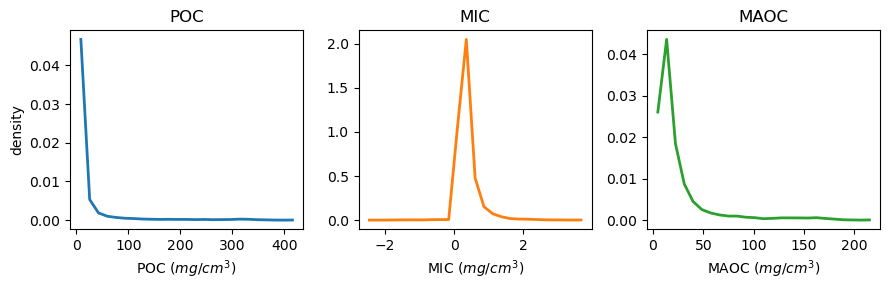

In [7]:
data = pd.read_pickle("1_preprocessed.pkl") # load pkl
maoc_cols = [
    "pred_MAOC_median_LinReg_inf_MAOC_index_2009",
    "pred_MAOC_median_LinReg_inf_MAOC_index_2015",
    "pred_MAOC_median_LinReg_inf_MAOC_index_2018",
]
mic_cols = [
    "pred_MIC_median_LinReg_inf_Cmic_index_2009",
    "pred_MIC_median_LinReg_inf_Cmic_index_2015",
    "pred_MIC_median_LinReg_inf_Cmic_index_2018",
]
r_maoc_avg = data[maoc_cols].mean(axis=1)
r_mic_avg = data[mic_cols].mean(axis=1)
Cb = data["OC_avg_09_15_18"] * r_mic_avg
Cm = data["OC_avg_09_15_18"] * (1-r_mic_avg) * r_maoc_avg
Cp = data["OC_avg_09_15_18"] * (1-r_mic_avg) * (1-r_maoc_avg)

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(9,3), sharey=False)

for i, (data_arr, pool, color) in enumerate(
        zip([Cp, Cb, Cm], ["POC", "MIC", "MAOC"], ["tab:blue", "tab:orange", "tab:green"])):
    ax = axes[i]
    # Remove non-finite values for nan-stable histograms
    clean_data = np.asarray(data_arr)
    clean_data = clean_data[np.isfinite(clean_data)]
    if len(clean_data) == 0:
        ax.text(0.5, 0.5, "No Data", ha="center", va="center")
        continue
    counts, bin_edges = np.histogram(clean_data, bins=25, density=True)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    ax.plot(bin_centers, counts, color=color, label=pool, lw=2)
    ax.set_title(pool)
    ax.set_xlabel(f"{pool} ($mg/cm^3$)")
    if i == 0:
        ax.set_ylabel("density")

plt.tight_layout()
plt.savefig("figures/obs_stocks_hist.png", dpi=300, bbox_inches="tight")
plt.show()

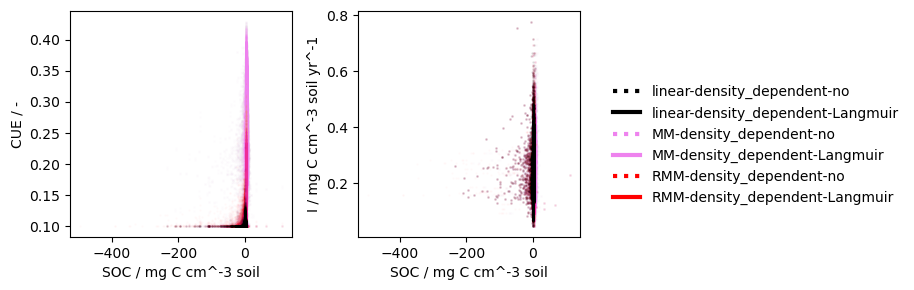

In [8]:
### SOC vs parameter(s) # colorcode mt
from config import default_param_ranges, default_param_ranges

def plot_SOC_vs_params(selected, parameters):
    n_params = len(parameters)
    fig, axes = plt.subplots(1, n_params, figsize=(3*n_params, 3), squeeze=False)
    axes = axes[0]  # since nrow=1

    for ax, parameter in zip(axes, parameters):
        for version in selected['version']:
            files = [f for f in all_files
                    if version in f
                    and f"{'SOC-MAOCi-MICi'}_" in f
                    and f"tempdynamic_fold" in f
                    ]
            files = sorted(files, key=len, reverse=True)
            optimal_row = selected[selected['version'] == version]
            opt = optimal_row["optimal n_sp"].values[0]
            files = files[folds*opt:folds*opt+folds]
            all_SOC = []
            all_parameter = []
            for file in files:
                data = pd.read_pickle(os.path.join(results_path, file))
                pools = np.asarray(data[['pred_final_Cp','pred_final_Cb','pred_final_Cm']], dtype=np.float32)
                SOC = list(pools.sum(axis=1))  # sum Cp, Cb, Cm to SOC
                param_vals = list(data[[f'param_{parameter}']].values)
                all_SOC.append(SOC)
                all_parameter.append(param_vals)
            style = versions[version]
            flat_SOC = [item for sublist in all_SOC for item in sublist]
            flat_param = [item for sublist in all_parameter for item in sublist]
            ax.scatter(flat_SOC, flat_param,
                label=version,
                color=style["color"],
                s=1,
                alpha=0.01)

        ax.set_ylabel(parameter + " / " + default_param_ranges[parameter]["unit"])
        ax.set_xlabel(f"SOC" + " / " + "mg C cm^-3 soil")

    # Create legend outside on the right
    legend_elements = []
    for version, style in versions.items():
        legend_elements.append(
            Line2D(
                [0], [0],
                color=style["color"],
                linestyle=style["texture"],
                linewidth=style["linewidth"],
                label=style["legend"],
            )
        )
    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.,
        frameon=False)
    plt.tight_layout()
    plt.savefig("figures/SOC_vs_params.png", dpi=300, bbox_inches="tight")
    plt.show()

# Example usage with previous parameters:
plot_SOC_vs_params(selected, ["CUE", "I"])

In [ ]:
### SOC vs parameter(s) # colorcode mt
from config import default_param_ranges, default_param_ranges

def plot_SOC_vs_params(selected, parameters):
    n_params = len(parameters)
    fig, axes = plt.subplots(1, n_params, figsize=(3*n_params, 3), squeeze=False)
    axes = axes[0]  # since nrow=1

    for ax, parameter in zip(axes, parameters):
        for version in selected['version']:
            files = [f for f in all_files
                    if version in f
                    and f"{'SOC-MAOCi-MICi'}_" in f
                    and f"tempdynamic_fold" in f
                    ]
            files = sorted(files, key=len, reverse=True)
            optimal_row = selected[selected['version'] == version]
            opt = optimal_row["optimal n_sp"].values[0]
            files = files[folds*opt:folds*opt+folds]
            all_SOC = []
            all_parameter = []
            for file in files:
                data = pd.read_pickle(os.path.join(results_path, file))
                pools = np.asarray(data[['pred_final_Cp','pred_final_Cb','pred_final_Cm']], dtype=np.float32)
                SOC = list(pools.sum(axis=1))  # sum Cp, Cb, Cm to SOC
                param_vals = list(data[[f'param_{parameter}']].values)
                all_SOC.append(SOC)
                all_parameter.append(param_vals)
            style = versions[version]
            flat_SOC = [item for sublist in all_SOC for item in sublist]
            flat_param = [item for sublist in all_parameter for item in sublist]
            ax.scatter(flat_SOC, flat_param,
                label=version,
                color=style["color"],
                s=1,
                alpha=0.01)

        ax.set_ylabel(parameter + " / " + default_param_ranges[parameter]["unit"])
        ax.set_xlabel(f"SOC" + " / " + "mg C cm^-3 soil")

    # Create legend outside on the right
    legend_elements = []
    for version, style in versions.items():
        legend_elements.append(
            Line2D(
                [0], [0],
                color=style["color"],
                linestyle=style["texture"],
                linewidth=style["linewidth"],
                label=style["legend"],
            )
        )
    fig.legend(
        handles=legend_elements,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.,
        frameon=False)
    plt.tight_layout()
    plt.savefig("figures/SOC_vs_params.png", dpi=300, bbox_inches="tight")
    plt.show()

# Example usage with previous parameters:
plot_SOC_vs_params(selected, ["CUE", "I"])

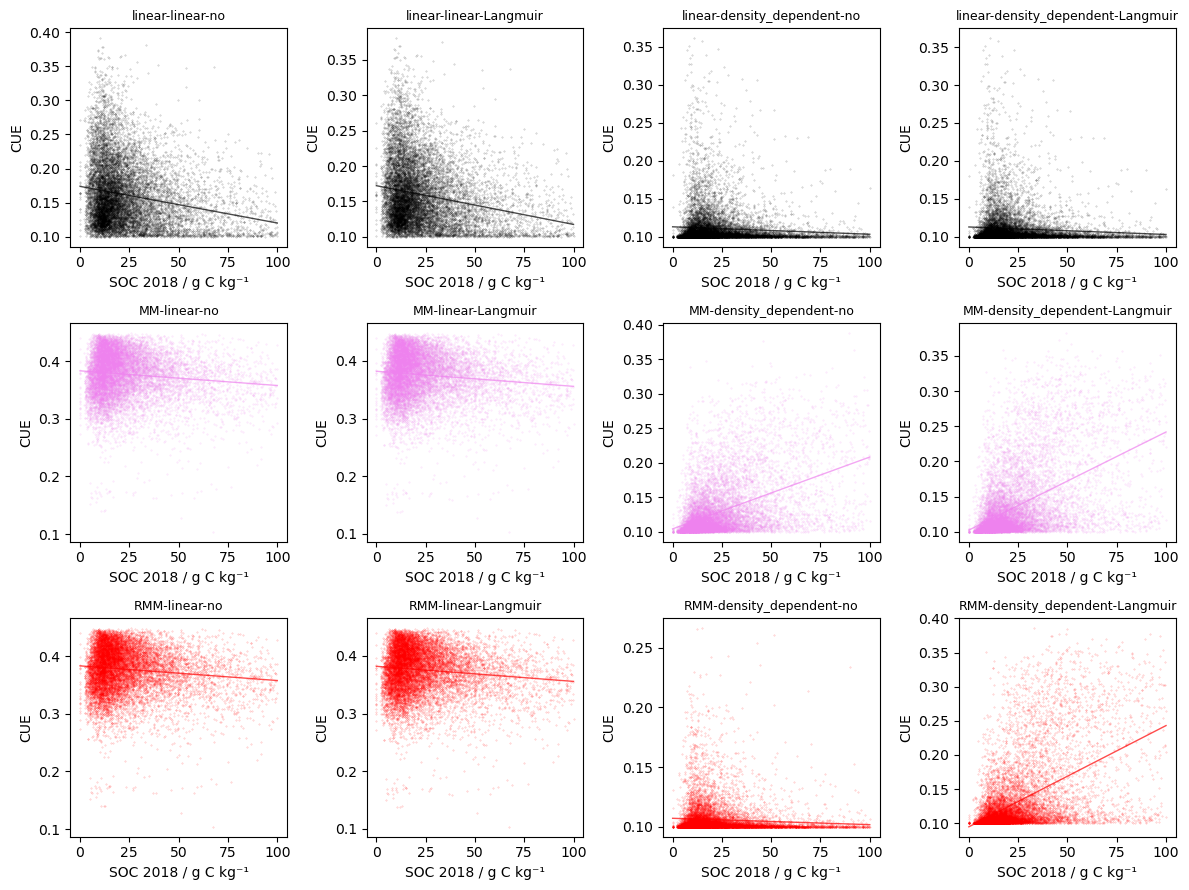

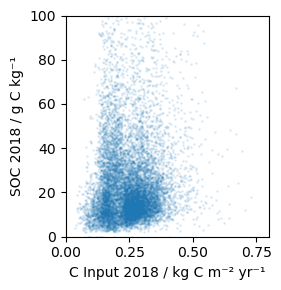

In [70]:
# CUE vs SOC
# 3 spatially varying, fold 1, dynamic
data = pd.read_pickle("1_preprocessed.pkl")  # load pkl

n_versions = len(versions)
ncols = 4
nrows = int(np.ceil(n_versions / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), squeeze=False)
axes = axes.flatten()

for idx, (version, style) in enumerate(versions.items()):
    ax = axes[idx]
    files = [
        f for f in all_files
        if version in f
        and f"{'SOC-MAOCi-MICi'}_" in f
        and f"tempdynamic_fold1" in f
    ]
    files = sorted(files, key=len, reverse=True)
    if not files:
        ax.set_visible(False)
        continue
    file = files[2] if len(files) > 2 else files[0]
    hybrid_data = pd.read_pickle(os.path.join(results_path, file))

    # Align indices if possible
    soc = data.loc[hybrid_data.index, 'OC_2018'] if np.all(hybrid_data.index.isin(data.index)) else data['OC_2018'][:len(hybrid_data)]
    cue = hybrid_data['param_CUE']

    # Take min length in case of mismatch
    n = min(len(soc), len(cue))
    soc_plot = soc.iloc[:n] if hasattr(soc, "iloc") else soc[:n]
    cue_plot = cue.iloc[:n] if hasattr(cue, "iloc") else cue[:n]

    # Convert to arrays for filtering
    soc_arr = np.array(soc_plot)
    cue_arr = np.array(cue_plot)

    # Remove entries where either is nan
    mask = (~np.isnan(soc_arr)) & (~np.isnan(cue_arr))
    soc_arr_clean = soc_arr[mask]
    cue_arr_clean = cue_arr[mask]

    # Filter out points where SOC > 100
    soc_below_max_mask = soc_arr_clean <= 100
    soc_arr_clean = soc_arr_clean[soc_below_max_mask]
    cue_arr_clean = cue_arr_clean[soc_below_max_mask]

    ax.scatter(
        soc_arr_clean,
        cue_arr_clean, 
        color=style["color"], alpha=0.3, label=style["legend"], s=0.1
    )

    # Add linear regression line only if >1 point and not all NaN
    if len(soc_arr_clean) > 1:
        from sklearn.linear_model import LinearRegression
        X_vals = soc_arr_clean.reshape(-1, 1)
        y_vals = cue_arr_clean
        model = LinearRegression()
        model.fit(X_vals, y_vals)
        x_range = np.linspace(X_vals.min(), X_vals.max(), 100).reshape(-1,1)
        y_pred = model.predict(x_range)
        ax.plot(x_range, y_pred, color=style["color"], linewidth=1, alpha=0.7)

    ax.set_xlabel('SOC 2018 / g C kg⁻¹')
    ax.set_ylabel('CUE')
    ax.set_title(style["legend"], fontsize=9)

# Hide any unused axes
for ax in axes[n_versions:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# I vs SOC
plt.figure(figsize=(3, 3))
plt.scatter(data['input_2018'], data['OC_2018'], alpha=0.1, s=1)
plt.xlabel('C Input 2018 / kg C m⁻² yr⁻¹')
plt.ylabel('SOC 2018 / g C kg⁻¹')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

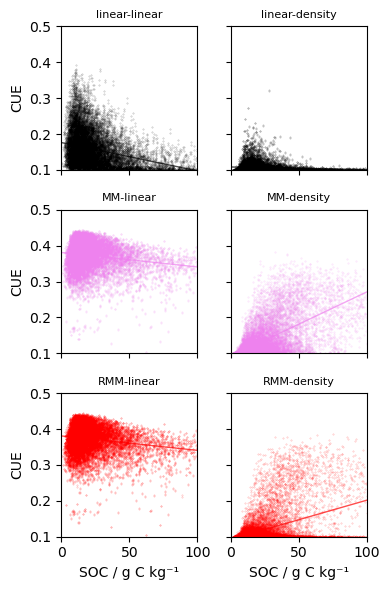

In [84]:
# CUE vs SOC
# 3 spatially varying, fold 1, dynamic

data = pd.read_pickle("1_preprocessed.pkl")  # load pkl

def extract_md_mt(version):
    try:
        parts = version.split('_')
        md = parts[0][2:]
        mt = parts[1][2:]
        return md, mt
    except Exception:
        return None, None

md_mt_dict = {}
for version, style in versions.items():
    md, mt = extract_md_mt(version)
    if md is None or mt is None:
        continue
    key = (md, mt)
    if key not in md_mt_dict:
        md_mt_dict[key] = {
            "color": style["color"],
            "linewidth": style["linewidth"],
            "legend": f"{md}-{mt}",
            "versions": [],
        }
    md_mt_dict[key]["versions"].append(version)

n_versions = len(md_mt_dict)
ncols = 2
nrows = 3

# ---- Collect all data to set same axes ----
all_soc_for_limits = []
all_cue_for_limits = []

soc_cue_by_subplot = []

for ((md, mt), vinfo) in md_mt_dict.items():
    soc_all = []
    cue_all = []
    for version in vinfo["versions"]:
        files = [
            f for f in all_files
            if version in f
            and f"{'SOC-MAOCi-MICi'}_" in f
            and f"tempdynamic_fold1" in f
        ]
        files = sorted(files, key=len, reverse=True)
        if not files:
            continue
        file = files[2] if len(files) > 2 else files[0]
        hybrid_data = pd.read_pickle(os.path.join(results_path, file))
        soc = data.loc[hybrid_data.index, 'OC_avg_09_15_18'] if np.all(hybrid_data.index.isin(data.index)) else data['OC_2018'][:len(hybrid_data)]
        cue = hybrid_data['param_CUE']
        n = min(len(soc), len(cue))
        soc_plot = soc.iloc[:n] if hasattr(soc, "iloc") else soc[:n]
        cue_plot = cue.iloc[:n] if hasattr(cue, "iloc") else cue[:n]
        soc_arr = np.array(soc_plot)
        cue_arr = np.array(cue_plot)
        mask = (~np.isnan(soc_arr)) & (~np.isnan(cue_arr))
        soc_arr_clean = soc_arr[mask]
        cue_arr_clean = cue_arr[mask]
        soc_below_max_mask = soc_arr_clean <= 100
        soc_arr_clean = soc_arr_clean[soc_below_max_mask]
        cue_arr_clean = cue_arr_clean[soc_below_max_mask]
        soc_all.append(soc_arr_clean)
        cue_all.append(cue_arr_clean)
    if soc_all and cue_all and any(len(s) > 0 for s in soc_all):
        soc_total = np.concatenate(soc_all)
        cue_total = np.concatenate(cue_all)
        # Save for axis limits
        all_soc_for_limits.append(soc_total)
        all_cue_for_limits.append(cue_total)
        soc_cue_by_subplot.append((soc_total, cue_total))
    else:
        soc_cue_by_subplot.append((None, None))

# Compute global axis limits
if all_soc_for_limits:
    soc_min = min([np.min(s) for s in all_soc_for_limits if len(s) > 0])
    soc_max = max([np.max(s) for s in all_soc_for_limits if len(s) > 0])
    # Instead of calculating cue_min and cue_max, we fix them to 0.1-0.5
    soc_min_plot = 0
    soc_max_plot = max(100, np.ceil(soc_max))
    cue_min_plot = 0.1
    cue_max_plot = 0.5
else:
    soc_min_plot, soc_max_plot = 0, 100
    cue_min_plot, cue_max_plot = 0.1, 0.5

# Make the subplots, then plot using collected data
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2), squeeze=False)
axes = axes.flatten()

for idx, ((md, mt), vinfo) in enumerate(md_mt_dict.items()):
    ax = axes[idx]
    soc_total, cue_total = soc_cue_by_subplot[idx]
    if soc_total is not None and cue_total is not None and len(soc_total) > 0:
        ax.scatter(
            soc_total,
            cue_total, 
            color=vinfo["color"], alpha=0.3, label=vinfo["legend"], s=0.1
        )
        # Regression line
        if len(soc_total) > 1:
            from sklearn.linear_model import LinearRegression
            X_vals = soc_total.reshape(-1, 1)
            y_vals = cue_total
            model = LinearRegression()
            model.fit(X_vals, y_vals)
            x_range = np.linspace(soc_min_plot, soc_max_plot, 100).reshape(-1,1)  # use axis limits for line
            y_pred = model.predict(x_range)
            ax.plot(x_range, y_pred, color=vinfo["color"], linewidth=1, alpha=0.7)
        row, col = divmod(idx, ncols)
        # Only put axis labels on left (y) and bottom (x) subplots
        if row == nrows - 1:
            ax.set_xlabel('SOC / g C kg⁻¹')
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel('CUE')
        else:
            ax.set_yticklabels([])
        ax.set_title(vinfo["legend"], fontsize=8)
        ax.set_xlim(soc_min_plot, soc_max_plot)
        ax.set_ylim(cue_min_plot, cue_max_plot)  # <-- Fixed y-axis to 0.1-0.5
    else:
        ax.set_visible(False)

# Hide any unused axes
for ax in axes[len(md_mt_dict):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

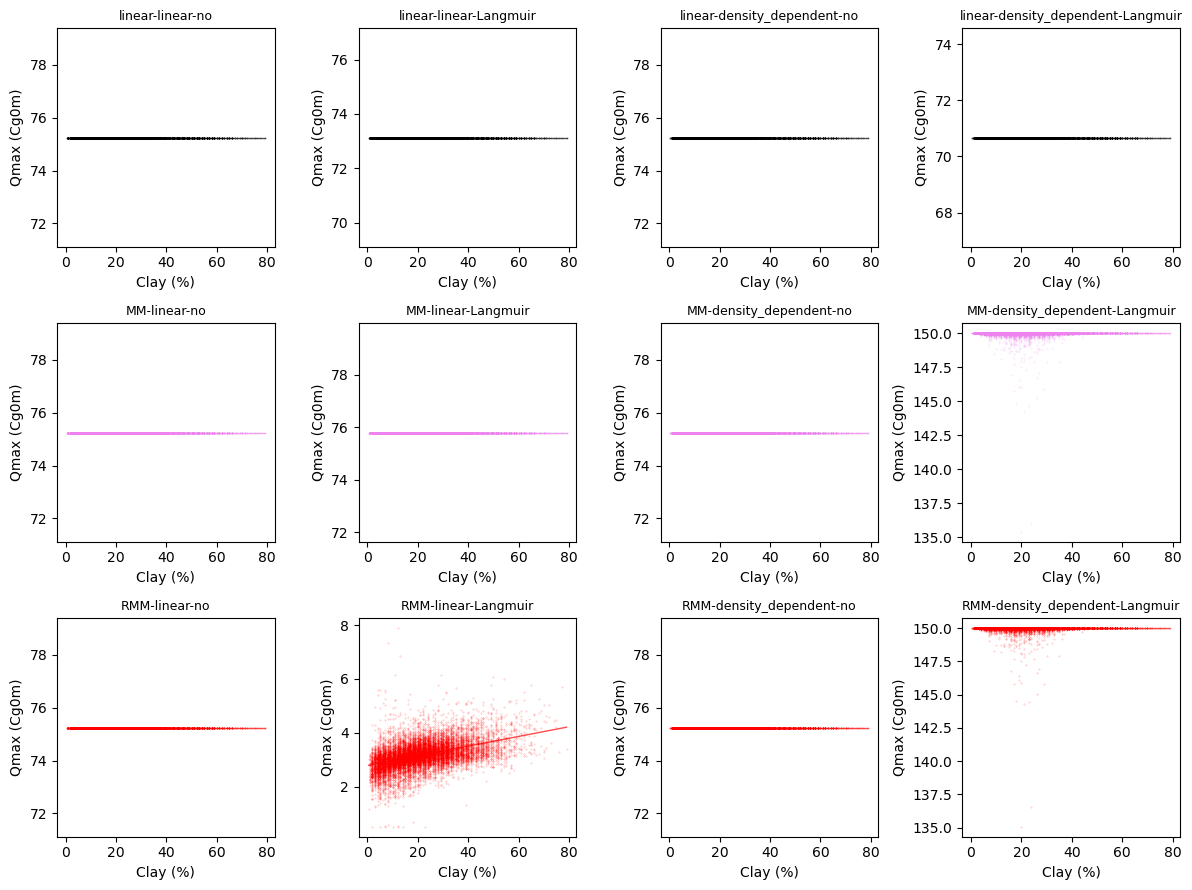

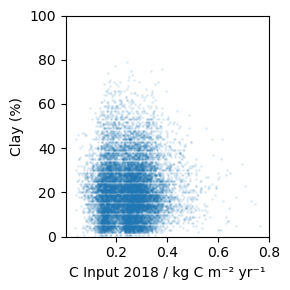

In [90]:
# Qmax (Cg0m) vs Clay
# 3 spatially varying, fold 1, dynamic
data = pd.read_pickle("1_preprocessed.pkl")  # load pkl

n_versions = len(versions)
ncols = 4
nrows = int(np.ceil(n_versions / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), squeeze=False)
axes = axes.flatten()

for idx, (version, style) in enumerate(versions.items()):
    ax = axes[idx]
    files = [
        f for f in all_files
        if version in f
        and f"{'SOC-MAOCi-MICi'}_" in f
        and f"tempstatic_fold1" in f
    ]
    files = sorted(files, key=len, reverse=True)
    if not files:
        ax.set_visible(False)
        continue
    file = files[4] if len(files) > 4 else files[0]
    hybrid_data = pd.read_pickle(os.path.join(results_path, file))

    # Align indices if possible
    clay = data.loc[hybrid_data.index, 'Clay'] if np.all(hybrid_data.index.isin(data.index)) else data['Clay'][:len(hybrid_data)]
    qmax = hybrid_data['param_Cg0m']  # Use Qmax

    # Take min length in case of mismatch
    n = min(len(clay), len(qmax))
    clay_plot = clay.iloc[:n] if hasattr(clay, "iloc") else clay[:n]
    qmax_plot = qmax.iloc[:n] if hasattr(qmax, "iloc") else qmax[:n]

    # Convert to arrays for filtering
    clay_arr = np.array(clay_plot)
    qmax_arr = np.array(qmax_plot)

    # Remove entries where either is nan
    mask = (~np.isnan(clay_arr)) & (~np.isnan(qmax_arr))
    clay_arr_clean = clay_arr[mask]
    qmax_arr_clean = qmax_arr[mask]

    # Filter out points where Clay > 100
    clay_below_max_mask = clay_arr_clean <= 100
    clay_arr_clean = clay_arr_clean[clay_below_max_mask]
    qmax_arr_clean = qmax_arr_clean[clay_below_max_mask]

    ax.scatter(
        clay_arr_clean,
        qmax_arr_clean, 
        color=style["color"], alpha=0.3, label=style["legend"], s=0.1
    )

    # Add linear regression line only if >1 point and not all NaN
    if len(clay_arr_clean) > 1:
        from sklearn.linear_model import LinearRegression
        X_vals = clay_arr_clean.reshape(-1, 1)
        y_vals = qmax_arr_clean
        model = LinearRegression()
        model.fit(X_vals, y_vals)
        x_range = np.linspace(X_vals.min(), X_vals.max(), 100).reshape(-1,1)
        y_pred = model.predict(x_range)
        ax.plot(x_range, y_pred, color=style["color"], linewidth=1, alpha=0.7)

    ax.set_xlabel('Clay (%)')
    ax.set_ylabel('Qmax (Cg0m)')
    ax.set_title(style["legend"], fontsize=9)

# Hide any unused axes
for ax in axes[n_versions:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# I vs Clay
plt.figure(figsize=(3, 3))
plt.scatter(data['input_2018'], data['Clay'], alpha=0.1, s=1)
plt.xlabel('C Input 2018 / kg C m⁻² yr⁻¹')
plt.ylabel('Clay (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [9]:
versions = {}
for md in ["linear", "MM", "RMM"]:
    for mt in ["density_dependent", "linear"]:
        for sat in ["no", "Langmuir"]:
            file_sub_str = f"md{md}_mt{mt}_sat{sat}"

            # colors by md
            color_map = {
                "linear": "black",   # linear md -> black
                "MM": "violet",      # MM -> violet
                "RMM": "red",        # RMM -> red
            }

            # line width by mt
            linewidth = 1 if mt == "linear" else 3  # linear mt thin, density_dependent thick

            # line style by saturation
            linestyle = ":" if sat == "no" else "-"  # no saturation dotted, Langmuir continuous

            versions[file_sub_str] = {
                "color": color_map[md],
                "texture": linestyle,          # reuse existing 'texture' field for linestyle
                "linewidth": linewidth,
                "legend": f"{md}-{mt}-{sat}",
                "md": md,
                "mt": mt,
                "sat": sat,
            }

for v in versions.keys():
    print(v)

mdlinear_mtdensity_dependent_satno
mdlinear_mtdensity_dependent_satLangmuir
mdlinear_mtlinear_satno
mdlinear_mtlinear_satLangmuir
mdMM_mtdensity_dependent_satno
mdMM_mtdensity_dependent_satLangmuir
mdMM_mtlinear_satno
mdMM_mtlinear_satLangmuir
mdRMM_mtdensity_dependent_satno
mdRMM_mtdensity_dependent_satLangmuir
mdRMM_mtlinear_satno
mdRMM_mtlinear_satLangmuir


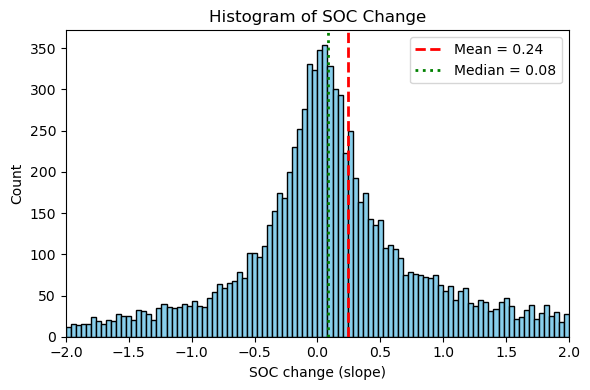

In [10]:
# hist. of SOC change
SOC_change = data['SOC_linreg_slope']
mean_SOC_change = SOC_change.mean()
median_SOC_change = SOC_change.median()
plt.figure(figsize=(6,4))
plt.hist(SOC_change.dropna(), bins=np.linspace(-2, 2, 101), color='skyblue', edgecolor='black')
plt.axvline(mean_SOC_change, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mean_SOC_change:.2f}")
plt.axvline(median_SOC_change, color='green', linestyle='dotted', linewidth=2, label=f"Median = {median_SOC_change:.2f}")
plt.xlabel("SOC change (slope)")
plt.ylabel("Count")
plt.title("Histogram of SOC Change")
plt.xlim(-2, 2)
plt.legend()
plt.tight_layout()
plt.show()


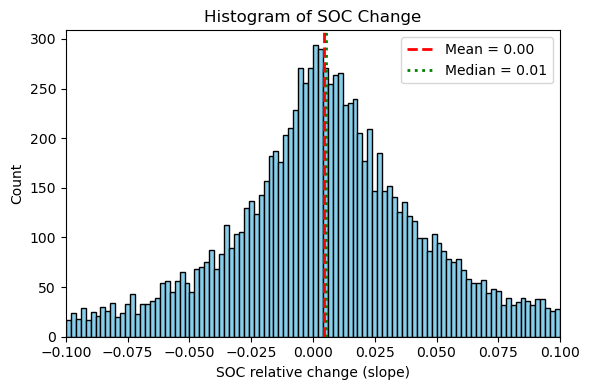

POINT_ID
gps_lat_2006
gps_long_2006
lc1_2006
survey_date_2006
gps_lat_2009
gps_long_2009
lc1_2009
survey_date_2009
gps_lat_2012
gps_long_2012
lc1_2012
survey_date_2012
gps_lat_2015
gps_long_2015
lc1_2015
survey_date_2015
gps_lat_2018
gps_long_2018
lc1_2018
survey_date_2018
pH_CaCl2_2018
OC_2018
CaCO3_2018
P_2018
N_2018
K_2018
Ox_Al_2018
Ox_Fe_2018
Coarse_2015
Clay_2015
Sand_2015
Silt_2015
pH_CaCl2_2015
OC_2015
CaCO3_2015
P_2015
N_2015
K_2015
Coarse_2012
Clay_2012
Silt_2012
Sand_2012
pH_CaCl2_2012
OC_2012
CaCO3_2012
N_2012
P_2012
K_2012
Coarse_2009
Clay_2009
Silt_2009
Sand_2009
pH_CaCl2_2009
OC_2009
CaCO3_2009
N_2009
P_2009
K_2009
BD 0-20_2018
OC_pom_g_kg_2009
OC_sc_g_kg_2009
OC_pom_g_kg_HS_2009
OC_sc_g_kg_HS_2009
Cmic_2018
Soil_Group
year
lc1_2_2018
lc1_2_2015
lc1_2_2009
Clay
Silt
Sand
Coarse
MAOC_index_2009
Cmic_index_2018
Calc_2009
CaCO3_c_2009
pH_c_2009
pH_2009
Calc_2012
CaCO3_c_2012
pH_c_2012
pH_2012
Calc_2015
CaCO3_c_2015
pH_c_2015
pH_2015
Calc_2018
CaCO3_c_2018
pH_c_2018
pH_2018


In [11]:
# hist. of SOC change
width = 0.1
SOC_change = data['SOC_linreg_slope']
SOC_value = data['OC_avg_09_15_18']
SOC_change = SOC_change / SOC_value
mean_SOC_change = SOC_change.mean()
median_SOC_change = SOC_change.median()
plt.figure(figsize=(6,4))
plt.hist(SOC_change.dropna(), bins=np.linspace(-width, width, 101), color='skyblue', edgecolor='black')
plt.axvline(mean_SOC_change, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mean_SOC_change:.2f}")
plt.axvline(median_SOC_change, color='green', linestyle='dotted', linewidth=2, label=f"Median = {median_SOC_change:.2f}")
plt.xlabel("SOC relative change (slope)")
plt.ylabel("Count")
plt.title("Histogram of SOC Change")
plt.xlim(-width, width)
plt.legend()
plt.tight_layout()
plt.show()

for i in data.columns.values:
    print(i)

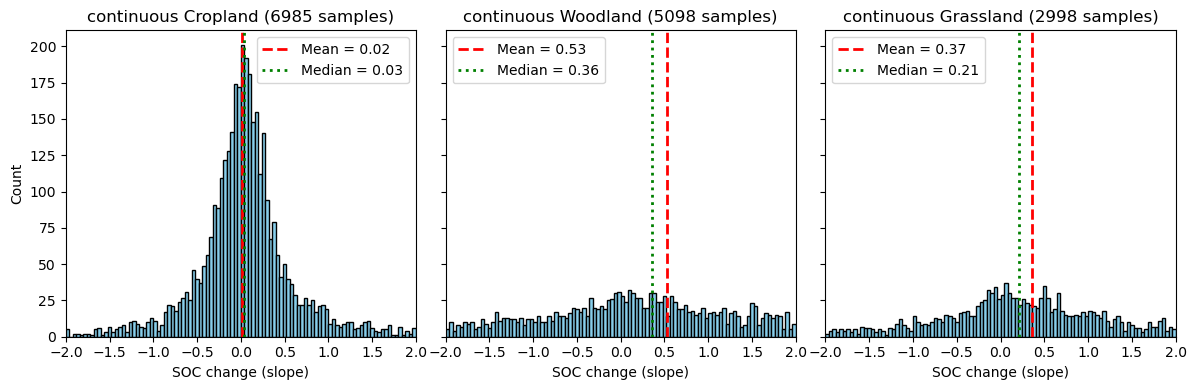

In [12]:
# SOC change hists per LC (only constant)
lc_list = ['A', 'B', 'C', 'E', 'F', 'G', 'H']
# Only plot those with count > 100
valid_lc_data = []
valid_lc_labels = []
for lc in lc_list:
    lc_data = data[data[f'LC_change_09_15_18_{lc}_{lc}_{lc}'] == True]
    if len(lc_data) > 100:
        valid_lc_data.append(lc_data)
        valid_lc_labels.append(lc)

# Mapping of LC codes to LUCAS LC descriptions based on common usage:
lc_to_lucas = {
    'A': 'Artificial land',
    'B': 'Cropland',
    'C': 'Woodland',
    'E': 'Grassland',
    'F': 'Shrubland',
    'G': 'Bare land',
    'H': 'Water'
}

fig, axes = plt.subplots(1, len(valid_lc_data), figsize=(4 * len(valid_lc_data), 4), sharey=True)
if len(valid_lc_data) == 1:
    axes = [axes]  # ensure iterable if only one LC

for ax, lc_data, lc in zip(axes, valid_lc_data, valid_lc_labels):
    SOC_change = lc_data['SOC_linreg_slope']
    mean_SOC_change = SOC_change.mean()
    median_SOC_change = SOC_change.median()
    ax.hist(SOC_change.dropna(), bins=np.linspace(-2, 2, 101), color='skyblue', edgecolor='black')
    ax.axvline(mean_SOC_change, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mean_SOC_change:.2f}")
    ax.axvline(median_SOC_change, color='green', linestyle='dotted', linewidth=2, label=f"Median = {median_SOC_change:.2f}")
    ax.set_xlabel("SOC change (slope)")
    ax.set_xlim(-2, 2)
    ax.set_title(f"continuous {lc_to_lucas[lc]} ({len(lc_data)} samples)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()


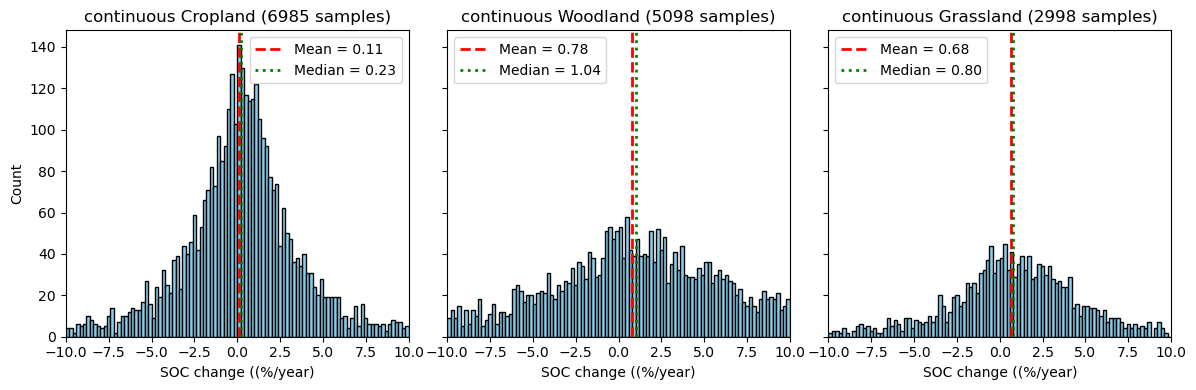

In [24]:
# SOC change hists per LC (only constant)
lc_list = ['A', 'B', 'C', 'E', 'F', 'G', 'H']
# Only plot those with count > 100
valid_lc_data = []
valid_lc_labels = []
for lc in lc_list:
    lc_data = data[data[f'LC_change_09_15_18_{lc}_{lc}_{lc}'] == True]
    if len(lc_data) > 100:
        valid_lc_data.append(lc_data)
        valid_lc_labels.append(lc)

# Mapping of LC codes to LUCAS LC descriptions based on common usage:
lc_to_lucas = {
    'A': 'Artificial land',
    'B': 'Cropland',
    'C': 'Woodland',
    'E': 'Grassland',
    'F': 'Shrubland',
    'G': 'Bare land',
    'H': 'Water'
}

fig, axes = plt.subplots(1, len(valid_lc_data), figsize=(4 * len(valid_lc_data), 4), sharey=True)
if len(valid_lc_data) == 1:
    axes = [axes]  # ensure iterable if only one LC

for ax, lc_data, lc in zip(axes, valid_lc_data, valid_lc_labels):
    SOC_change = lc_data['SOC_linreg_slope']
    SOC_value = lc_data['OC_avg_09_15_18']
    SOC_change = SOC_change *100 / SOC_value
    mean_SOC_change = SOC_change.mean()
    median_SOC_change = SOC_change.median()
    ax.hist(SOC_change.dropna(), bins=np.linspace(-width*100, width*100, 101), color='skyblue', edgecolor='black')
    ax.axvline(mean_SOC_change, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mean_SOC_change:.2f}")
    ax.axvline(median_SOC_change, color='green', linestyle='dotted', linewidth=2, label=f"Median = {median_SOC_change:.2f}")
    ax.set_xlabel("SOC change ((%/year)")
    ax.set_xlim(-width*100, width*100)
    ax.set_title(f"continuous {lc_to_lucas[lc]} ({len(lc_data)} samples)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_2979864/3500328237.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, showfliers=False)


Linear regression slope (per year): -0.00044547203650434683


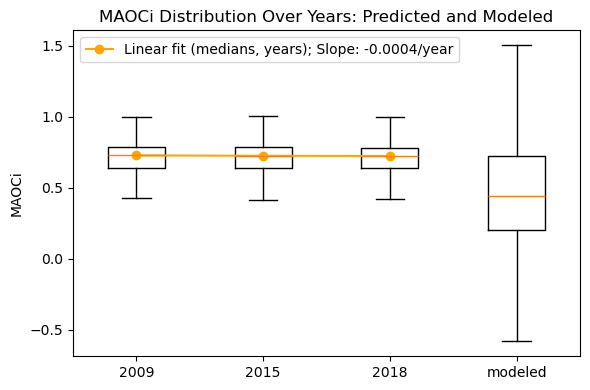

In [14]:
# boxplots: MAOCi over the years + modeled: 4
folds = 3
MAOCis = {2009: [], 2015: [], 2018: []}
for fld in range(10):
    for year in [2009, 2015, 2018]:
        MAOCis[year].extend(list(data[f'pred_MAOC_fold{fld}_LinReg_inf_MAOC_index_{year}'].values))
MAOCis['modeled'] = []
for version in versions:
    files = [f for f in all_files
                    if version in f
                    and f"{'SOC-MAOCi-MICi'}_" in f
                    and f"tempdynamic_fold" in f]
    files = sorted(files, key=len, reverse=True)
    for file in files[-3:]: # max n_sp
        modeled_data = pd.read_pickle(os.path.join(results_path, file))
        MAOCi_modeled = modeled_data['pred_final_Cm'] / (modeled_data['pred_final_Cm'] + modeled_data['pred_final_Cp'])
        MAOCis['modeled'].extend(list(MAOCi_modeled))
# Boxplot for the 4 variables in MAOCis
plt.figure(figsize=(6, 4))
labels = list(MAOCis.keys())
data_to_plot = [MAOCis[year] for year in labels]
plt.boxplot(data_to_plot, labels=labels, showfliers=False)
plt.ylabel("MAOCi")
plt.title("MAOCi Distribution Over Years: Predicted and Modeled")
plt.tight_layout()

# Add a linear regression on the medians of the three years (using the year values as x)
import scipy.stats

# Extract only numeric years, exclude 'modeled'
year_labels = [year for year in labels if isinstance(year, int)]
x = np.array(year_labels)  # x = [2009, 2015, 2018]
y = np.array([np.median(MAOCis[year]) for year in year_labels])  # medians for 2009, 2015, 2018

# Perform linear regression (year vs median MAOCi)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)

# Print the slope
print("Linear regression slope (per year):", slope)

# Overlay regression line on the boxplot for the 3 year positions
box_positions = [labels.index(year) + 1 for year in year_labels]
regression_y = intercept + slope * x
plt.plot(box_positions, regression_y, color='orange', linestyle='-', marker='o', label=f'Linear fit (medians, years); Slope: {slope:.4f}/year')


plt.legend()
plt.show()

/tmp/ipykernel_2979864/4646907.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, showfliers=False)


Linear regression slope (per year): -1.4278721839776618e-05


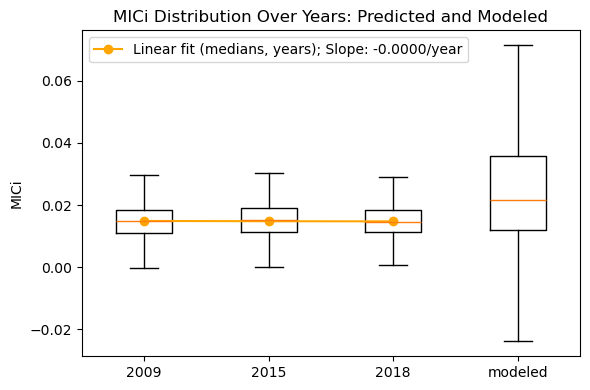

In [27]:
# boxplots: MAOCi over the years + modeled: 4
folds = 3
MAOCis = {2009: [], 2015: [], 2018: []}
for fld in range(10):
    for year in [2009, 2015, 2018]:
        MAOCis[year].extend(list(data[f'pred_MIC_fold{fld}_LinReg_inf_Cmic_index_{year}'].values))
MAOCis['modeled'] = []
for version in versions:
    files = [f for f in all_files
                    if version in f
                    and f"{'SOC-MAOCi-MICi'}_" in f
                    and f"tempdynamic_fold" in f]
    files = sorted(files, key=len, reverse=True)
    for file in files[-3:]: # max n_sp
        modeled_data = pd.read_pickle(os.path.join(results_path, file))
        MAOCi_modeled = modeled_data['pred_final_Cb'] / (modeled_data['pred_final_Cb'] + modeled_data['pred_final_Cm'] + modeled_data['pred_final_Cp'])
        MAOCis['modeled'].extend(list(MAOCi_modeled))
# Boxplot for the 4 variables in MAOCis
plt.figure(figsize=(6, 4))
labels = list(MAOCis.keys())
data_to_plot = [MAOCis[year] for year in labels]
plt.boxplot(data_to_plot, labels=labels, showfliers=False)
plt.ylabel("MICi")
plt.title("MICi Distribution Over Years: Predicted and Modeled")
plt.tight_layout()

# Add a linear regression on the medians of the three years (using the year values as x)
import scipy.stats

# Extract only numeric years, exclude 'modeled'
year_labels = [year for year in labels if isinstance(year, int)]
x = np.array(year_labels)  # x = [2009, 2015, 2018]
y = np.array([np.median(MAOCis[year]) for year in year_labels])  # medians for 2009, 2015, 2018

# Perform linear regression (year vs median MAOCi)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x, y)

# Print the slope
print("Linear regression slope (per year):", slope)

# Overlay regression line on the boxplot for the 3 year positions
box_positions = [labels.index(year) + 1 for year in year_labels]
regression_y = intercept + slope * x
plt.plot(box_positions, regression_y, color='orange', linestyle='-', marker='o', label=f'Linear fit (medians, years); Slope: {slope:.4f}/year')


plt.legend()
plt.show()

/tmp/ipykernel_2979864/1248592883.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot([C_N_ratios[year].dropna() for year in [2009, 2015, 2018]],


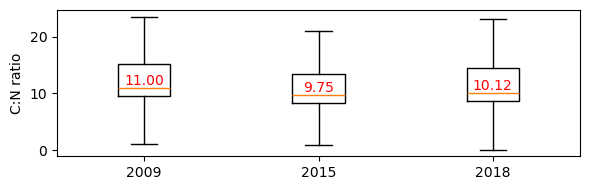

In [29]:
# boxplots: C:N over years: 3
C_N_ratios = {}
medians = {}
for year in [2009, 2015, 2018]:
    C_N_ratios[year] = data[f'OC_{year}'] / data[f'N_{year}']
    medians[year] = C_N_ratios[year].median()

plt.figure(figsize=(6, 2))
bplot = plt.boxplot([C_N_ratios[year].dropna() for year in [2009, 2015, 2018]],
            labels=[2009, 2015, 2018], showfliers=False)
plt.ylabel("C:N ratio")

# Show the median values on the plot above each box
for i, year in enumerate([2009, 2015, 2018]):
    plt.text(i + 1, medians[year], f"{medians[year]:.2f}", 
             ha='center', va='bottom', fontsize=10, color='red')

plt.tight_layout()
plt.show()

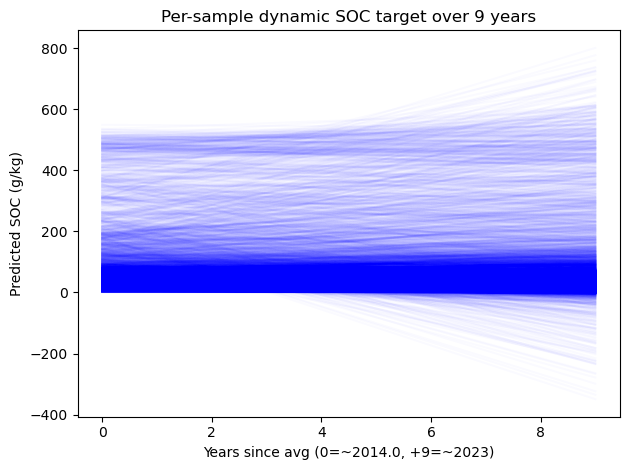

In [17]:
# plot the dynamic target: start at avg and then go 9 years... any negative?
SOC_change = data['SOC_linreg_slope']
SOC_value = data['OC_avg_09_15_18']
for i in range(len(SOC_value)):
    plt.plot([0, 9], [SOC_value.iat[i], SOC_value.iat[i] + SOC_change.iat[i] * 9], alpha=0.02, color='blue')
plt.xlabel('Years since avg (0=~2014.0, +9=~2023)')
plt.ylabel('Predicted SOC (g/kg)')
plt.title('Per-sample dynamic SOC target over 9 years')
plt.tight_layout()
plt.show()

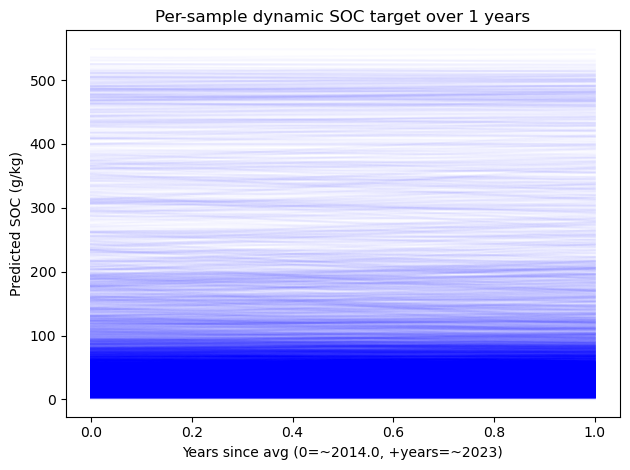

In [18]:
# plot the dynamic target: start at avg and then go years years... any negative?
years = 1
SOC_change = data['SOC_linreg_slope']
SOC_value = data['OC_avg_09_15_18']
for i in range(len(SOC_value)):
    plt.plot([0, years], [SOC_value.iat[i], SOC_value.iat[i] + SOC_change.iat[i] * years], alpha=0.02, color='blue')
plt.xlabel('Years since avg (0=~2014.0, +years=~2023)')
plt.ylabel('Predicted SOC (g/kg)')
plt.title(f'Per-sample dynamic SOC target over {years} years')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2979864/1032555936.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_2979864/1032555936.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_2979864/1032555936.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


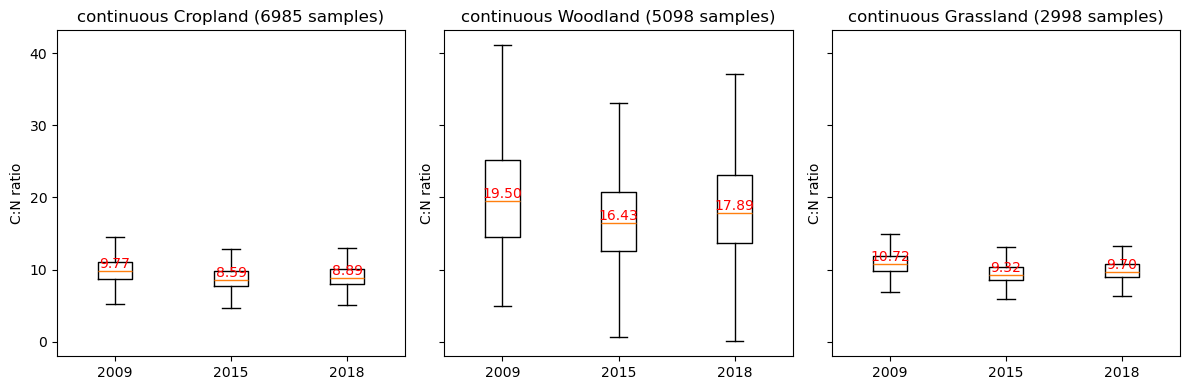

In [19]:
# Per-LC boxplots: C:N over years: 3 (like first cell style)
lc_list = ['A', 'B', 'C', 'E', 'F', 'G', 'H']  # use LC groups as per cell 1
valid_lc_data = []
valid_lc_labels = []
min_samples = 100  # only plot if >100 samples

for lc in lc_list:
    lc_data = data[data[f'LC_change_09_15_18_{lc}_{lc}_{lc}'] == True]
    if len(lc_data) > min_samples:
        valid_lc_data.append(lc_data)
        valid_lc_labels.append(lc)

lc_to_lucas = {
    'A': 'Artificial land',
    'B': 'Cropland',
    'C': 'Woodland',
    'E': 'Grassland',
    'F': 'Shrubland',
    'G': 'Bare land',
    'H': 'Water'
}

fig, axes = plt.subplots(1, len(valid_lc_data), figsize=(4 * len(valid_lc_data), 4), sharey=True)
if len(valid_lc_data) == 1:
    axes = [axes]  # ensure iterable if only one LC

for ax, lc_data, lc in zip(axes, valid_lc_data, valid_lc_labels):
    C_N_ratios = {year: lc_data[f'OC_{year}'] / lc_data[f'N_{year}'] for year in [2009, 2015, 2018]}
    medians = {year: C_N_ratios[year].median() for year in [2009, 2015, 2018]}
    box = ax.boxplot(
        [C_N_ratios[year].dropna() for year in [2009, 2015, 2018]],
        labels=[2009, 2015, 2018],
        showfliers=False
    )
    ax.set_ylabel("C:N ratio")
    ax.set_title(f"continuous {lc_to_lucas[lc]} ({len(lc_data)} samples)")
    # Show the median values on the plot above each box
    for i, year in enumerate([2009, 2015, 2018]):
        ax.text(i + 1, medians[year], f"{medians[year]:.2f}", 
             ha='center', va='bottom', fontsize=10, color='red')
plt.tight_layout()
plt.show()

In [20]:
for i in data.columns.values:
    print(i)

POINT_ID
gps_lat_2006
gps_long_2006
lc1_2006
survey_date_2006
gps_lat_2009
gps_long_2009
lc1_2009
survey_date_2009
gps_lat_2012
gps_long_2012
lc1_2012
survey_date_2012
gps_lat_2015
gps_long_2015
lc1_2015
survey_date_2015
gps_lat_2018
gps_long_2018
lc1_2018
survey_date_2018
pH_CaCl2_2018
OC_2018
CaCO3_2018
P_2018
N_2018
K_2018
Ox_Al_2018
Ox_Fe_2018
Coarse_2015
Clay_2015
Sand_2015
Silt_2015
pH_CaCl2_2015
OC_2015
CaCO3_2015
P_2015
N_2015
K_2015
Coarse_2012
Clay_2012
Silt_2012
Sand_2012
pH_CaCl2_2012
OC_2012
CaCO3_2012
N_2012
P_2012
K_2012
Coarse_2009
Clay_2009
Silt_2009
Sand_2009
pH_CaCl2_2009
OC_2009
CaCO3_2009
N_2009
P_2009
K_2009
BD 0-20_2018
OC_pom_g_kg_2009
OC_sc_g_kg_2009
OC_pom_g_kg_HS_2009
OC_sc_g_kg_HS_2009
Cmic_2018
Soil_Group
year
lc1_2_2018
lc1_2_2015
lc1_2_2009
Clay
Silt
Sand
Coarse
MAOC_index_2009
Cmic_index_2018
Calc_2009
CaCO3_c_2009
pH_c_2009
pH_2009
Calc_2012
CaCO3_c_2012
pH_c_2012
pH_2012
Calc_2015
CaCO3_c_2015
pH_c_2015
pH_2015
Calc_2018
CaCO3_c_2018
pH_c_2018
pH_2018


FileNotFoundError: [Errno 2] No such file or directory: '5_with_predictions.pkl'

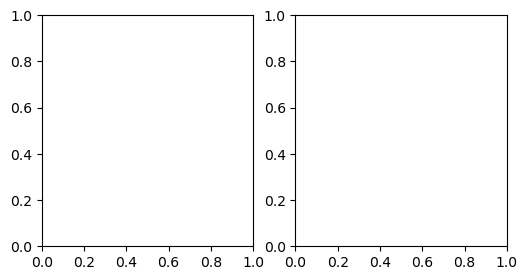

In [21]:
### new Qmax
def fine_fraction(Clay, Silt):
    """ % -> % """
    return Clay + Silt
def Qmax_Georgiou(fine_fraction, mineral_type):
    """ % -> gC/kg 
    mineral_type and fine_fraction can be scalars or numpy arrays.
    mineral_type: 1.0 = high-activity (kaolinite/smectite), 0.0 = low-activity (chlorite/illite), or array of these.
    """
    return np.where(
        mineral_type == 1.0,
        fine_fraction * 0.86,
        np.where(
            mineral_type == 0.0,
            fine_fraction * 0.48,
            np.nan # undefined if mineral_type not 0 or 1
        )
    )
def mass_to_volume_based(mass_based, BD):
    """ gC/kg & g/cm3 -> kgC/m3 """
    return mass_based*BD
def Georgiou(Clay, Silt, mineral_type, BD):
    """ output in kgC/m3 """
    fin_fra = fine_fraction(Clay, Silt)
    Qmax_mass_based = Qmax_Georgiou(fin_fra, mineral_type)
    Qmax_volume_based = mass_to_volume_based(Qmax_mass_based, BD)
    return Qmax_volume_based

def mineral_content(OC):
    """ g/kg -> %mass """
    return 1 - OC/1000
def fine_content(mineral_content, fine_fraction):
    """ %mass & %mass -> %mass=g fine particles per 100 g soil """
    return mineral_content*fine_fraction
def Qmax_Hassink(fine_content):
    """ g fine particles per 100 g soil -> mgC/g """
    return 0.37 * fine_content + 4.07
def Hassink(Clay, Silt, OC, BD):
    """ output in kgC/m3 """
    fin_fra = fine_fraction(Clay, Silt)
    min_con = mineral_content(OC)
    fin_con = fine_content(min_con, fin_fra)
    Qmax_mass_based = Qmax_Hassink(fin_con)
    Qmax_volume_based = mass_to_volume_based(Qmax_mass_based, BD)
    return Qmax_volume_based
    
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(2*3, 3)) # init plot
all_files = os.listdir(results_path) 

lucas = pd.read_pickle("5_with_predictions.pkl")
npp_year = "2015"
npp_col = f"MODIS_NPP_{npp_year}gps_{npp_year}"
npp_mask = (
    lucas[npp_col].notna()
    & np.isfinite(lucas[npp_col])
    & (lucas[npp_col] > 0)
).to_numpy()
print(np.count_nonzero(npp_mask))
original_idx = np.where(npp_mask)[0]
lucas = lucas.loc[npp_mask].reset_index(drop=True)
split = lucas['split']
### select Langmuir+ss+MAOC/POC
selected_Qmax_versions = ["mdMM_mtlinear_satLangmuir", "mdlinear_mtdensity_dependent_satLangmuir", "mdlinear_mtlinear_satLangmuir"]
for version in selected_Qmax_versions: # loop over versions
    files = [f for f in all_files # get files
            if version in f
            and f"fold{0}" in f
            and f"{'Cp-Cm'}_" in f
            and f"temp2018_fold" in f
            ]
    files = sorted(files, key=len, reverse=True)
    opt = res_2015_2018[res_2015_2018["version"] == version]["optimal n_sp"].values[0]
    max = res_2015_2018[res_2015_2018["version"] == version]["max n_sp"].values[0] -2 # use max instead of opt to include Qmax
    file = files[opt]
    all_predicted_Qmax = [] 
    all_Hassink = [] 
    all_Georgiou = []
    
    # for fold, file in enumerate(files): # loop over folds
    data = pd.read_pickle(os.path.join(results_path, file)) # load pkl
    all_predicted_Qmax += list(data[['param_Cg0m']].values)
    Clay = lucas[['Clay']].values
    Silt = lucas[['Silt']].values
    OC = lucas[['OC_2018']].values
    BD = lucas[['pred_BD_median_LinReg_inf_BD_0-20_2018']].values # use predicted
    mineral_type = lucas[['HALA_2018gps_topsoil']].values
    all_Hassink += list(Hassink(Clay, Silt, OC, BD))
    all_Georgiou += list(Georgiou(Clay, Silt, mineral_type, BD))
    style = versions[version]
    print('all_predicted_Qmax', len(all_predicted_Qmax))
    print('all_Hassink', len(all_Hassink))
    print('all_Georgiou', len(all_Georgiou))
    axes[0].scatter(all_predicted_Qmax, all_Hassink, label=version, color=style["color"], s=1, alpha=0.01)
    axes[1].scatter(all_predicted_Qmax, all_Georgiou, label=version, color=style["color"], s=1, alpha=0.01)
    print()
    # min = np.min([np.nanmin(all_predicted_Qmax), np.nanmin(all_Hassink), np.nanmin(all_Georgiou)])
    # max = np.max([np.nanmax(all_predicted_Qmax), np.nanmax(all_Hassink), np.nanmax(all_Georgiou)])
    # axes[0].plot([min, max], [min, max], 'k--', alpha=0.5)
    # axes[1].plot([min, max], [min, max], 'k--', alpha=0.5)

# for ax, name in zip(axes, ['Hassink', 'Georgiou']):
#     ax.set_ylabel(f'{name} Qmax')
#     ax.set_xlabel(f"learned Qmax")

# legend_elements = []
# for version, style in versions.items():
#     legend_elements.append(
#         Line2D(
#             [0], [0],
#             color=style["color"],
#             linestyle=style["texture"],
#             linewidth=style["linewidth"],
#             label=style["legend"],   # or label=version
#         )
#     )
# fig.legend(
#     handles=legend_elements,
#     loc="center left",
#     bbox_to_anchor=(1.02, 0.5),
#     borderaxespad=0.,
#     frameon=False)
# plt.tight_layout()
# plt.savefig("figures/Qmax.png", dpi=300, bbox_inches="tight")
# plt.show() # legend

In [ ]:
# SfT - Plot distribution of *time until steady state* (FAST)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import diffrax as dfx
from functools import partial
from hybrid_models import craig_BA_adapt, analytical_steady_state
from hybrid_utils import vector_field

_SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
results_path = os.path.join(_SCRIPT_DIR, results_path)
folds = 5
# ~10% of rows for speed (deterministic stride so progress totals stay correct)
SAMPLE_FRAC = 1.0#0.1
# Integration: sparse saves (was steps=True @ dt=0.2 → ~1500 steps/save)
T_END = 2500.0
DT_INTEGRATOR = 5.0
_SAVE_TS = jnp.linspace(0.0, T_END, int(T_END / DT_INTEGRATOR) + 1)
BATCH_CHUNK = 1024


def make_analytical_batch(md, mt, sat):
    """Vectorized steady state for fixed (md, mt, sat) — avoids Python loop over rows."""

    @jax.jit
    def batch(params_batch):
        return jax.vmap(
            lambda p: analytical_steady_state(
                p,
                microbial_decomposition=md,
                microbial_turnover=mt,
                saturation=sat,
            )
        )(params_batch)

    return batch


def subsample_df(df):
    n = len(df)
    if n == 0:
        return df
    step = max(1, int(round(1.0 / SAMPLE_FRAC)))
    return df.iloc[::step].reset_index(drop=True)

# From 7_analysis.ipynb adaptability grid (Cp-Cb-Cm, 2015_2018); override via selected_versions.csv
OPTIMAL_N_SP_DEFAULT = {
    "mdlinear_mtdensity_dependent_satLangmuir": 5,
    "mdlinear_mtdensity_dependent_satno": 6,
    "mdMM_mtdensity_dependent_satLangmuir": 5,
    "mdMM_mtdensity_dependent_satno": 5,
    "mdRMM_mtdensity_dependent_satLangmuir": 5,
    "mdRMM_mtdensity_dependent_satno": 5,
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(3*3, 3)) # 3 subplots (3 pools)
versions = {}
for md in ["linear", "MM", "RMM"]:
    for mt in ["density_dependent"]:
        for sat in ["no", "Langmuir"]:
            file_sub_str = f"md{md}_mt{mt}_sat{sat}"
            color_map = {
                "linear": "black",
                "MM": "violet",
                "RMM": "red",
            }
            linewidth = 1 if md == "linear" else 3
            linestyle = ":" if sat == "no" else "-"
            versions[file_sub_str] = {
                "color": color_map[md],
                "texture": linestyle,
                "linewidth": linewidth,
                "legend": f"{md}-{mt}-{sat}",
            }

all_files = os.listdir(results_path)

_csv = os.path.join(_SCRIPT_DIR, "selected_versions.csv")
if os.path.isfile(_csv):
    selected = pd.read_csv(_csv)
else:
    selected = pd.DataFrame(
        [{"version": v, "optimal n_sp": n} for v, n in OPTIMAL_N_SP_DEFAULT.items()]
    )

# ------------------------------------------------------------
# JAX‑accelerated batch integration
# ------------------------------------------------------------
def make_batch_integrator(md, mt, sat):
    """Returns a JIT‑compiled function that integrates a batch of simulations."""
    model_fn = partial(craig_BA_adapt,
                       microbial_decomposition=md,
                       microbial_turnover=mt,
                       saturation=sat)

    @jax.jit
    def solve_batch(y0_batch, params_batch, ss_batch):
        # solve_one will be vmapped over the batch
        def solve_one(y0, params, ss):
            term = dfx.ODETerm(partial(vector_field, model_fn))
            solver = dfx.Euler()
            saveat = dfx.SaveAt(ts=_SAVE_TS)
            sol = dfx.diffeqsolve(
                term,
                solver,
                t0=0.0,
                t1=T_END,
                dt0=DT_INTEGRATOR,
                y0=y0,
                args=params,
                saveat=saveat,
            )
            ys = sol.ys        # (n_steps, 3)
            ts = sol.ts        # (n_steps,)

            # For each pool, find first time it's within 1e-3 relative tolerance
            close_enough = jnp.abs(ys - ss) < 1e-3 * (jnp.abs(ss) + 1e-6)
            def first_true(col):
                idx = jnp.argmax(col)
                return jnp.where(col[idx], ts[idx], jnp.nan)
            return jax.vmap(first_true, in_axes=1)(close_enough)

        # Vectorize over the batch
        batched = jax.vmap(solve_one, in_axes=(0, 0, 0))
        return batched(y0_batch, params_batch, ss_batch)

    return solve_batch

# ------------------------------------------------------------
# Process each version (same as before, but inner loop is batched)
# ------------------------------------------------------------
for version in versions:
    files = [f for f in all_files
            if version in f
            and f"{'Cp-Cb-Cm'}_" in f
            and f"temp2015_2018_fold" in f
            ]
    files = sorted(files, key=len, reverse=True)
    opt = selected[selected["version"] == version]["optimal n_sp"].values[0]
    files = files[folds*opt:folds*opt+folds]

    times_steady_all = [[] for _ in range(3)] # Cp, Cb, Cm
    # version format: md{md}_mt{mt}_sat{sat} — mt may contain underscores (e.g. density_dependent)
    parts = version.split("_")
    md = parts[0][2:]
    sat = parts[-1][3:]  # satno / satLangmuir / …
    mt = "_".join(parts[1:-1])[2:]  # strip leading "mt" from mtdensity_dependent…

    batch_integrator = make_batch_integrator(md, mt, sat)
    analytical_batch = make_analytical_batch(md, mt, sat)

    batches = []
    for file in files:
        data = subsample_df(pd.read_pickle(os.path.join(results_path, file)))
        batches.append(data)
    total_to_run = sum(len(d) for d in batches)

    counter = 0
    print(f"\nProcessing version: {version} (~{100 * SAMPLE_FRAC:.0f}% of rows)")

    for data in batches:
        params_arr = data[['param_I','param_CUE','param_beta','param_tmb','param_Cg0b','param_Cg0m','param_qx','param_Vmax_p','param_Vmax_m','param_Km_p','param_Km_m','param_kp','param_kb','param_km']].values.astype(np.float32)
        y0_arr = data[[f'pred_final_{pool}' for pool in ["Cp", "Cb", "Cm"]]].values.astype(np.float32)

        params_jax = jnp.asarray(params_arr)
        ss_parts = []
        for s in range(0, params_jax.shape[0], BATCH_CHUNK):
            e = min(s + BATCH_CHUNK, params_jax.shape[0])
            ss_parts.append(analytical_batch(params_jax[s:e]))
        ss_batch = jnp.concatenate(ss_parts, axis=0)

        y0_batch = jnp.array(y0_arr)

        nloc = y0_arr.shape[0]
        time_chunks = []
        for s in range(0, nloc, BATCH_CHUNK):
            e = min(s + BATCH_CHUNK, nloc)
            time_chunks.append(
                batch_integrator(y0_batch[s:e], params_jax[s:e], ss_batch[s:e])
            )
        times_batch = jnp.concatenate(time_chunks, axis=0)

        times_batch_np = np.array(times_batch)
        for i in range(3):
            times_steady_all[i].extend(times_batch_np[:, i])

        counter += len(y0_arr)
        print(f"\r{version} {counter}/{total_to_run} ({100*counter/total_to_run:.1f}%)", end="", flush=True)

    print("") # finish line

    # Plot densities (exactly as before)
    for i, pool in enumerate(["Cp", "Cb", "Cm"]):
        ax = axes[i]
        arr = np.array(times_steady_all[i])
        arr = arr[np.isfinite(arr)]
        if len(arr) == 0:
            continue
        counts, bin_edges = np.histogram(arr, bins=25, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        style = versions[version]
        ax.plot(bin_centers, counts,
                label=version,
                color=style["color"], linestyle=style["texture"], linewidth=style["linewidth"])

# (Rest of plotting unchanged)
axes[0].set_ylabel('density')
for i, pool in enumerate(["POC", "MIC", "MAOC"]):
    ax = axes[i]
    ax.set_title(pool)
    ax.set_xlabel(f"{pool} time to steady state (years)")

legend_elements = []
for version, style in versions.items():
    legend_elements.append(
        Line2D(
            [0], [0],
            color=style["color"],
            linestyle=style["texture"],
            linewidth=style["linewidth"],
            label=style["legend"],
        )
    )

fig.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False)
plt.tight_layout()
_figdir = os.path.join(_SCRIPT_DIR, "figures")
os.makedirs(_figdir, exist_ok=True)
plt.savefig(os.path.join(_figdir, "time2steady.png"), dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Wrote {os.path.join(_figdir, 'time2steady.png')}")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import numpy as np
import pandas as pd
folds = 5
res_2015_2018 = pd.read_csv("figures/res_2015_2018.csv")


versions = {}
for md in ["linear", "MM", "RMM"]:
    for mt in ["density_dependent", "linear"]:
        for sat in ["no", "Langmuir"]:
            file_sub_str = f"md{md}_mt{mt}_sat{sat}"

            # colors by md
            color_map = {
                "linear": "black",   # linear md -> black
                "MM": "violet",      # MM -> violet
                "RMM": "red",        # RMM -> red
            }

            # line width by mt
            linewidth = 1 if mt == "linear" else 3  # linear mt thin, density_dependent thick

            # line style by saturation
            linestyle = ":" if sat == "no" else "-"  # no saturation dotted, Langmuir continuous

            versions[file_sub_str] = {
                "color": color_map[md],
                "texture": linestyle,          # reuse existing 'texture' field for linestyle
                "linewidth": linewidth,
                "legend": f"{md}-{mt}-{sat}",
                "md": md,
                "mt": mt,
                "sat": sat,
            }
### new Qmax
def fine_fraction(Clay, Silt):
    """ % -> % """
    return Clay + Silt
def Qmax_Georgiou(fine_fraction, mineral_type):
    """ % -> gC/kg 
    mineral_type and fine_fraction can be scalars or numpy arrays.
    mineral_type: 1.0 = high-activity (kaolinite/smectite), 0.0 = low-activity (chlorite/illite), or array of these.
    """
    return np.where(
        mineral_type == 1.0,
        fine_fraction * 0.86,
        np.where(
            mineral_type == 0.0,
            fine_fraction * 0.48,
            np.nan # undefined if mineral_type not 0 or 1
        )
    )
def mass_to_volume_based(mass_based, BD):
    """ gC/kg & g/cm3 -> kgC/m3 """
    return mass_based*BD
def Georgiou(Clay, Silt, mineral_type, BD):
    """ output in kgC/m3 """
    fin_fra = fine_fraction(Clay, Silt)
    Qmax_mass_based = Qmax_Georgiou(fin_fra, mineral_type)
    Qmax_volume_based = mass_to_volume_based(Qmax_mass_based, BD)
    return Qmax_volume_based

def mineral_content(OC):
    """ g/kg -> %mass """
    return 1 - OC/1000
def fine_content(mineral_content, fine_fraction):
    """ %mass & %mass -> %mass=g fine particles per 100 g soil """
    return mineral_content*fine_fraction
def Qmax_Hassink(fine_content):
    """ g fine particles per 100 g soil -> mgC/g """
    return 0.37 * fine_content + 4.07
def Hassink(Clay, Silt, OC, BD):
    """ output in kgC/m3 """
    fin_fra = fine_fraction(Clay, Silt)
    min_con = mineral_content(OC)
    fin_con = fine_content(min_con, fin_fra)
    Qmax_mass_based = Qmax_Hassink(fin_con)
    Qmax_volume_based = mass_to_volume_based(Qmax_mass_based, BD)
    return Qmax_volume_based
    
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(2*3, 3)) # init plot
all_files = os.listdir(results_path) 

lucas = pd.read_pickle("5_with_predictions.pkl")
npp_year = "2015"
npp_col = f"MODIS_NPP_{npp_year}gps_{npp_year}"
npp_mask = (
    lucas[npp_col].notna()
    & np.isfinite(lucas[npp_col])
    & (lucas[npp_col] > 0)
).to_numpy()
# Keep original row ids so we can align with hybrid outputs (indexed like 6_hybrid.py).
lucas_masked = lucas.loc[npp_mask]
### select Langmuir+ss+MAOC/POC
selected_Qmax_versions = ["mdMM_mtlinear_satLangmuir", "mdlinear_mtdensity_dependent_satLangmuir", "mdlinear_mtlinear_satLangmuir"]
# Distinct colors (global `versions` only colors by md, so both linear-md models were black).
selected_qmax_colors = {
    "mdMM_mtlinear_satLangmuir": "violet",
    "mdlinear_mtdensity_dependent_satLangmuir": "#e67e22",
    "mdlinear_mtlinear_satLangmuir": "#1a7f37",
}
for version in selected_Qmax_versions: # loop over versions
    files = [f for f in all_files # get files
            if version in f
            and f"fold{0}" in f
            and f"{'Cp-Cm'}_" in f
            and f"temp2018_fold" in f
            ]
    files = sorted(files, key=len, reverse=True)
    opt = res_2015_2018[res_2015_2018["version"] == version]["optimal n_sp"].values[0]
    max = res_2015_2018[res_2015_2018["version"] == version]["max n_sp"].values[0] -2 # use max instead of opt to include Qmax
    file = files[opt]
    all_predicted_Qmax = [] 
    all_Hassink = [] 
    all_Georgiou = []
    
    # for fold, file in enumerate(files): # loop over folds
    data = pd.read_pickle(os.path.join(results_path, file)) # load pkl
    # Hybrid may have been run on a different NPP mask than current; keep rows in both.
    keep_idx = data.index[data.index.isin(lucas_masked.index)]
    data = data.loc[keep_idx]
    lucas_aligned = lucas_masked.loc[keep_idx]
    all_predicted_Qmax += list(data[['param_Cg0m']].values)
    Clay = lucas_aligned[['Clay']].values
    Silt = lucas_aligned[['Silt']].values
    OC = lucas_aligned[['OC_2018']].values
    BD = lucas_aligned[['pred_BD_median_LinReg_inf_BD_0-20_2018']].values # use predicted
    mineral_type = lucas_aligned[['HALA_2018gps_topsoil']].values
    all_Hassink += list(Hassink(Clay, Silt, OC, BD))
    all_Georgiou += list(Georgiou(Clay, Silt, mineral_type, BD))
    style = versions[version]
    c = selected_qmax_colors[version]
    axes[0].scatter(all_predicted_Qmax, all_Hassink, label=version, color=c, s=1, alpha=0.01)
    axes[1].scatter(all_predicted_Qmax, all_Georgiou, label=version, color=c, s=1, alpha=0.01)

    min = np.min([np.nanmin(all_predicted_Qmax), np.nanmin(all_Hassink), np.nanmin(all_Georgiou)])
    max = np.max([np.nanmax(all_predicted_Qmax), np.nanmax(all_Hassink), np.nanmax(all_Georgiou)])
    axes[0].plot([min, max], [min, max], 'k--', alpha=0.5)
    axes[1].plot([min, max], [min, max], 'k--', alpha=0.5)

for ax, name in zip(axes, ['Hassink', 'Georgiou']):
    ax.set_ylabel(rf"{name} Qmax / kg C m$^{{-3}}$")
    ax.set_xlabel(r"learned Qmax / mg C cm$^{-3}$")

legend_elements = []
for version in selected_Qmax_versions:
    style = versions[version]
    legend_elements.append(
        Line2D(
            [0], [0],
            color=selected_qmax_colors[version],
            linestyle=style["texture"],
            linewidth=style["linewidth"],
            label=style["legend"],
        )
    )
fig.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.,
    frameon=False)
plt.tight_layout()
plt.savefig("figures/Qmax.png", dpi=300, bbox_inches="tight")
# plt.show() # legend